# Estimación de pH y Ca: CNN 1D + CNN 3D + clásicos con entrada de cubo

**Trabajo de grado — Sistema optoelectrónico hiperespectral tipo pushbroom | UIS, E3T**

| Modelo | Entrada |
|---|---|
| PLSR, Ridge, SVR, Random Forest | Firma `.MAT` de 84 bandas **y**, aparte, el resumen del cubo (media + desviación por banda, 168 valores) |
| **CNN 1D** (nueva) | Firma de 84 bandas del archivo `.MAT` |
| **CNN 3D** (la de la V18) | Cubo hiperespectral reducido a 84 bandas × 20 × 20 píxeles |

```
976 muestras
 ├── 10 % TEST  (98)  → congelado; se usa UNA vez, al final
 └── 90 % DESARROLLO (878)
        └── 5 folds: en cada uno, 4/5 entrena y 1/5 valida
```

- Cada configuración de cada modelo se entrena 5 veces, una por fold. Cada muestra del desarrollo recibe la predicción del modelo que no la vio. Con esas 878 predicciones se calculan `val_RMSE` y `val_R2`, y con eso se escoge todo (preprocesamiento, hiperparámetros y transformación del target).
- **Clásicos:** la configuración ganadora se reentrena con todo el desarrollo (90 %) y predice el test.
- **CNN:** las 5 redes del fold (una por fold) de la configuración ganadora predicen el test y se promedian.
- La validación usa 878 muestras en vez de 98: es mucho más estable que un solo 10 % de validation.

# 1. Librerías

In [1]:
import os
import re
import json
import time
import copy
import shutil
import random
import warnings
from pathlib import Path
from fractions import Fraction

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.signal import savgol_filter
from scipy.stats import trim_mean
import joblib

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("NumPy", np.__version__, "| pandas", pd.__version__)

NumPy 2.2.6 | pandas 2.3.3


In [2]:
# PyTorch va en una celda aparte para que sea fácil ver si falla la instalación o la GPU.
import torch
import torch.nn as nn

GPU_ID = 0      # si el servidor tiene varias GPU, cuál usar (el número que muestra nvidia-smi)

torch.set_num_threads(max(1, os.cpu_count() or 1))
print("PyTorch:", torch.__version__, "| CUDA de PyTorch:", torch.version.cuda)

if not torch.cuda.is_available():
    DEVICE = torch.device("cpu")
    print("Dispositivo: cpu (PyTorch no ve ninguna GPU). Las CNN entrenarán MUY lento.")
else:
    DEVICE = torch.device(f"cuda:{GPU_ID}")
    try:
        torch.cuda.set_device(DEVICE)
        _probe = torch.ones(1024, device=DEVICE) * 2
        torch.cuda.synchronize()
        del _probe
    except Exception as e:
        raise RuntimeError(
            f"No se pudo usar la GPU {GPU_ID}: {e}\n\n"
        ) from None
    torch.backends.cudnn.benchmark = True
    props = torch.cuda.get_device_properties(DEVICE)
    free, total = torch.cuda.mem_get_info(DEVICE)
    print(f"Dispositivo: {DEVICE} | GPU: {props.name} | memoria libre: {free / 1e9:.1f} de {total / 1e9:.1f} GB")
    print("OK: la GPU responde.")

PyTorch: 2.14.0+cu130 | CUDA de PyTorch: 13.0
Dispositivo: cuda:0 | GPU: NVIDIA TITAN RTX | memoria libre: 24.6 de 25.2 GB
OK: la GPU responde.


# 2. Configuración

Todo lo que se puede ajustar está aquí. Lo demás no debería necesitar cambios.

In [3]:
# =========================================================
# RUTAS
# =========================================================
BASE_DIR = Path("FIRMAS")
SPECTRA_DIR = BASE_DIR / "Firmas_84_bandas" / "MAT"      # carpeta con los Soil_XXX__84_Bandas.mat
GT_MAT_PATH = BASE_DIR / "gt" / "datos_gt.mat"           # si no existe, se busca el único .mat de la carpeta gt
GT_VAR_NAME = "gt"

MAT_REFLECTANCE_KEY = "reflectanciaSoil"
MAT_WAVELENGTH_KEY = "ejeBandas"

OUT_DIR = Path("resultados_V23")

# =========================================================
# CUBOS HIPERESPECTRALES (entrada de la CNN 3D)
# =========================================================
# Estructura esperada (se busca en TODAS las subcarpetas de CUBE_ROOT):
#   FIRMAS/cubos/resultados_cubos_soil_bandas/Soil_1__cube_20260617_171738/2px_84_bandas/
#       Soil_1__84_Bandas_cubo_recorte_cuadrado_reflectancia.npy   <- el cubo (180 x 180 x 84)
#       Soil_1__84_Bandas_mascara_soil.npy                         <- qué píxeles son suelo
#       Soil_1__84_Bandas_wavelengths_nm.npy                       <- eje espectral
CUBE_ROOT = BASE_DIR / "cubos"
CUBE_REFLECTANCE_PATTERN = "*84_Bandas*cubo*reflectancia*.npy"
CUBE_MASK_PATTERN = "*mascara_soil*.npy"
CUBE_WAVELENGTH_PATTERN = "*wavelengths_nm*.npy"
CUBE_FOLDER_HINT = "2px_84_bandas"   # solo cubos cuya ruta contenga este texto (None = cualquiera)
CUBE_USE_MASK = True                 # usar SOLO los píxeles marcados como suelo
CUBE_SPATIAL_STAT = "trimmed_mean"
CUBE_BORDER_PX = 0
CUBE_VALID_RANGE = (-0.05, 1.5)      # píxeles fuera de este rango se consideran defectuosos
CUBE3D_SIZE = 20                     # el cubo 180x180 se reduce a 20x20 promediando bloques de 9x9 píxeles
CUBE3D_MIN_VALID = 0.5               # un bloque necesita >= 50 % de píxeles válidos

# =========================================================
# DATASET
# =========================================================
EXPECTED_N_SAMPLES = 976
GT_COLUMN_NAMES = [
    "Numero", "Carbono", "pH", "Ca", "Mg", "Na", "K",
    "Al", "P", "B", "Fe", "Mn", "Cu", "Zn", "CiC", "CE",
]
TARGETS = ["pH", "Ca"]
WAVELENGTH_RANGE_NM = (None, None)   # p. ej. (400, 700) para usar solo el visible

# =========================================================
# PARTICIÓN (igual que la V18)
# =========================================================
RANDOM_STATE = 42
TEST_SIZE = 0.10
N_FOLDS = 5
STRATIFY_BINS = 4        # cuantiles de pH y Ca combinados para estratificar

# =========================================================
# PREPROCESAMIENTOS (se aplican en el orden escrito, separados por "+")
#   RAW : sin cambios | SG : suavizado Savitzky–Golay | ABS : log10(1/R)
#   (también existen SNV, MSC, D1 y CR, que en la V16 quedaron siempre de últimos)
# =========================================================
PREPROCESS_CANDIDATES = ["RAW", "SG", "ABS", "ABS+SG"]
SG_WINDOW = 11
SG_POLYORDER = 2

# Transformación del target. Ca es muy asimétrico (0.2 a 37), por eso se prueba
# también log1p. Las métricas SIEMPRE se reportan en la escala original.
TARGET_TRANSFORMS = {
    "pH": ["identity"],
    "Ca": ["identity", "log1p"],
}

# =========================================================
# MODELOS CLÁSICOS (se escogen por validación cruzada)
# =========================================================
# Además de la firma .MAT, los clásicos se entrenan con un resumen del cubo
# (media + desviación de los píxeles, por banda: 168 valores) para compararlos
# en igualdad de información con la CNN 3D.
CLASSICAL_CUBE_INPUTS = True
PLS_COMPONENTS = list(range(1, 21))
RIDGE_ALPHAS = [float(a) for a in np.logspace(-3, 3, 13)]
SVR_GRID = [
    {"C": C, "gamma": g, "epsilon": 0.1}
    for C in [1.0, 10.0, 100.0]
    for g in ["scale", 0.01, 0.001]
]
RF_GRID = [
    {"n_estimators": 300, "max_features": "sqrt", "min_samples_leaf": leaf}
    for leaf in [1, 5]
]

# =========================================================
# CNN (comunes a 1D y 3D)
# =========================================================
RUN_CNN_1D = True
RUN_CNN_3D = True

CNN_PREPROCESS_CANDIDATES = PREPROCESS_CANDIDATES.copy()
CNN_TARGET_TRANSFORM = "auto"   # "auto" = la que ganó en los clásicos (firma .MAT) para cada target

CNN_LOSS = "r2"                 # "r2" (loss = 1 - R², la de la V18), "mse" (error cuadrático medio) o "huber"
CNN_MAX_EPOCHS = 300
CNN_MIN_EPOCHS = 10             # no se acepta un "mejor" antes de esta época
CNN_PATIENCE = 30               # épocas sin mejorar (val loss suavizada) antes de parar
CNN_SMOOTH_WINDOW = 5
CNN_BATCH_SIZE = 32
CNN_LR = 3e-4
CNN_WEIGHT_DECAY = 1e-2
CNN_LR_PATIENCE = 10            # ReduceLROnPlateau
CNN_LR_FACTOR = 0.5
CNN_MIN_LR = 1e-5
CNN_DROPOUT = 0.30
CNN_WIDTH = {"1D": 16, "3D": 8}   # filtros de la primera capa; luego 2x y 4x

# Aumento de datos (SOLO en train): ganancia, desplazamiento y ruido pequeños;
# en la 3D además rotaciones de 90° y espejos del cubo (el suelo no tiene orientación).
CNN_AUGMENT = True
AUG_SCALE = 0.02
AUG_OFFSET = 0.01
AUG_NOISE = 0.01
CNN_TTA_3D = True               # en la 3D, validación/test promedian las 8 rotaciones/espejos

# =========================================================
# MODO RÁPIDO (para probar que todo corre)
# =========================================================
QUICK_MODE = False
if QUICK_MODE:
    PREPROCESS_CANDIDATES = ["RAW", "ABS"]
    CNN_PREPROCESS_CANDIDATES = ["RAW"]
    CNN_MAX_EPOCHS = 30
    CNN_MIN_EPOCHS = 5
    CNN_PATIENCE = 10
    PLS_COMPONENTS = [2, 5, 10]
    RIDGE_ALPHAS = [0.1, 10.0]
    SVR_GRID = SVR_GRID[:2]
    RF_GRID = RF_GRID[:1]

N_BOOTSTRAP = 2000

# =========================================================
# CARPETAS DE SALIDA
# =========================================================
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = OUT_DIR / "figuras"
MODEL_DIR = OUT_DIR / "modelos"
TABLE_DIR = OUT_DIR / "tablas"
for d in [FIG_DIR, MODEL_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)


def savefig(name):
    plt.savefig(FIG_DIR / f"{name}.png", dpi=300, bbox_inches="tight")


def set_numpy_seed(seed):
    random.seed(seed)
    np.random.seed(seed)


set_numpy_seed(RANDOM_STATE)
print("Resultados en:", OUT_DIR.resolve())

Resultados en: /home/gpu3/Documents/Nohelia/resultados_V23


# 3. Lectura de archivos `.mat`

In [4]:
def load_mat(path):
    """Lee un .mat clásico con scipy; si es MATLAB v7.3 usa h5py."""
    path = Path(path)
    try:
        d = sio.loadmat(path, squeeze_me=True, simplify_cells=True)
        return {k: v for k, v in d.items() if not k.startswith("__")}
    except NotImplementedError:
        import h5py
        with h5py.File(path, "r") as f:
            return {k: np.asarray(f[k][()]) for k in f.keys()}


def parse_soil_id(path):
    m = re.search(r"Soil[_-]?(\d+)", Path(path).name, flags=re.IGNORECASE)
    if m:
        return int(m.group(1))
    m = re.search(r"(\d+)", Path(path).name)
    return int(m.group(1)) if m else None


def as_vector(value, name, path):
    arr = np.squeeze(np.asarray(value, dtype=float))
    if arr.ndim != 1:
        raise ValueError(f"{Path(path).name}: '{name}' no es un vector 1D (shape {arr.shape}).")
    return arr


if not SPECTRA_DIR.exists():
    raise FileNotFoundError(f"No existe la carpeta de firmas: {SPECTRA_DIR.resolve()}")

if not GT_MAT_PATH.exists():
    candidates = sorted((BASE_DIR / "gt").glob("*.mat"))
    if len(candidates) == 1:
        GT_MAT_PATH = candidates[0]
    else:
        raise FileNotFoundError(
            f"No existe {GT_MAT_PATH}. Archivos .mat en la carpeta gt: {[p.name for p in candidates]}"
        )

mat_files = sorted(SPECTRA_DIR.glob("*.mat"), key=lambda p: (parse_soil_id(p) or 0))
print("Archivos .mat de firmas:", len(mat_files))
print("GT:", GT_MAT_PATH)

example = load_mat(mat_files[0])
print("\nVariables del primer archivo:", mat_files[0].name)
for k, v in example.items():
    a = np.asarray(v)
    print(f"  {k:28s} shape={str(a.shape):8s} dtype={a.dtype}")

Archivos .mat de firmas: 976
GT: FIRMAS/gt/datos_gt.mat

Variables del primer archivo: Soil_1__84_Bandas.mat
  reflectanciaSoil             shape=(84,)    dtype=float64
  ejeBandas                    shape=(84,)    dtype=float64
  reflectanciaSoilOriginal     shape=(84,)    dtype=float64
  bandasOriginal               shape=(84,)    dtype=float64
  sourceRow                    shape=(84,)    dtype=float64
  posicionEquivalenteSoil      shape=(84,)    dtype=float64
  metodoSeleccion              shape=()       dtype=<U31
  targetLength                 shape=()       dtype=int64
  pixelStep                    shape=()       dtype=int64
  cubeId                       shape=()       dtype=<U6
  archivoOrigen                shape=()       dtype=<U21


# 4. Cargar firmas `.MAT`, ground truth y cubos

In [5]:
def load_all_signatures(files):
    ids, spectra, wls = [], [], []
    for p in files:
        sid = parse_soil_id(p)
        if sid is None:
            raise ValueError(f"No se pudo leer el ID de {p.name}")
        d = load_mat(p)
        r = as_vector(d[MAT_REFLECTANCE_KEY], MAT_REFLECTANCE_KEY, p)
        w = as_vector(d[MAT_WAVELENGTH_KEY], MAT_WAVELENGTH_KEY, p)
        if len(r) != len(w):
            raise ValueError(f"{p.name}: reflectancia ({len(r)}) y eje ({len(w)}) de distinto tamaño.")
        ids.append(sid)
        spectra.append(r)
        wls.append(w)

    lengths = {len(s) for s in spectra}
    if len(lengths) != 1:
        raise ValueError(f"No todas las firmas tienen el mismo número de bandas: {lengths}")
    ids = np.asarray(ids, dtype=int)
    if len(np.unique(ids)) != len(ids):
        raise ValueError("Hay IDs de firma repetidos.")

    W = np.vstack(wls)
    wl = np.median(W, axis=0)
    max_dev = float(np.max(np.abs(W - wl)))
    if max_dev > 1.0:
        raise ValueError(f"El eje de longitudes de onda cambia hasta {max_dev:.2f} nm entre archivos.")
    return ids, np.vstack(spectra).astype(np.float64), wl


def load_gt(path, var_name):
    d = load_mat(path)
    if var_name not in d:
        raise KeyError(f"'{var_name}' no está en {path}. Variables: {list(d)}")
    gt = np.squeeze(np.asarray(d[var_name], dtype=float))
    if gt.ndim != 2:
        raise ValueError(f"El GT debe ser una matriz 2D, shape={gt.shape}")
    if gt.shape[0] <= len(GT_COLUMN_NAMES) + 2 and gt.shape[1] > gt.shape[0]:
        gt = gt.T
    ncol = gt.shape[1]
    cols = GT_COLUMN_NAMES[:ncol] + [f"Var_{i}" for i in range(len(GT_COLUMN_NAMES), ncol)]
    frame = pd.DataFrame(gt, columns=cols)
    frame["Numero"] = frame["Numero"].round().astype(int)
    if frame["Numero"].duplicated().any():
        raise ValueError("Hay IDs repetidos en el GT.")
    return frame


ids_mat, X_mat, wavelengths = load_all_signatures(mat_files)
gt_df = load_gt(GT_MAT_PATH, GT_VAR_NAME)

common = np.array([i for i in ids_mat if i in set(gt_df["Numero"])], dtype=int)
row_of = {sid: k for k, sid in enumerate(ids_mat)}
X_raw_mat = X_mat[[row_of[i] for i in common]]
df = gt_df.set_index("Numero").loc[common].reset_index()

# Quitar muestras sin valor en algún target.
ok = df[TARGETS].notna().all(axis=1).to_numpy()
df = df.loc[ok].reset_index(drop=True)
X_raw_mat = X_raw_mat[ok]

print("Firmas leídas:", len(ids_mat), "| filas GT:", len(gt_df), "| emparejadas:", len(df))
print("Firmas sin GT:", sorted(set(ids_mat) - set(gt_df["Numero"])))
print("Bandas:", len(wavelengths), f"({wavelengths.min():.0f}–{wavelengths.max():.0f} nm)")
if len(df) != EXPECTED_N_SAMPLES:
    print(f"ATENCIÓN: se esperaban {EXPECTED_N_SAMPLES} muestras y hay {len(df)}.")
display(df[["Numero"] + TARGETS].describe().T)

Firmas leídas: 976 | filas GT: 976 | emparejadas: 976
Firmas sin GT: []
Bandas: 84 (400–1301 nm)


,count,mean,std,min,25%,50%,75%,max
Numero,976.0,497.093238,285.154811,1.00,249.7500,497.50,743.25,993.0
pH,976.0,4.861475,0.858819,4.00,4.2000,4.60,5.30,7.6
Ca,976.0,8.190338,8.107994,0.18,2.1275,4.82,12.20,36.8


In [6]:
# ---------------------------------------------------------
# Firmas medias y cubos reducidos a partir de los cubos .npy
# ---------------------------------------------------------
def _timestamp_key(path):
    # 'Soil_1__cube_20260617_171738' -> '20260617171738' (para quedarse con la toma más reciente).
    m = re.findall(r"(\d{8})_(\d{6})", str(path))
    return "".join(m[-1]) if m else ""


def find_cubes(root):
    # Devuelve {Numero: info del cubo elegido} y avisa de duplicados.
    by_id = {}
    for p in Path(root).rglob(CUBE_REFLECTANCE_PATTERN):
        if CUBE_FOLDER_HINT and CUBE_FOLDER_HINT.lower() not in str(p).lower():
            continue
        sid = parse_soil_id(p)
        if sid is not None:
            by_id.setdefault(sid, []).append(p)
    chosen, n_dup = {}, 0
    for sid, paths in by_id.items():
        if len(paths) > 1:
            n_dup += 1
        p = max(paths, key=lambda q: (_timestamp_key(q), q.stat().st_mtime))
        masks = sorted(p.parent.glob(CUBE_MASK_PATTERN))
        wls = sorted(p.parent.glob(CUBE_WAVELENGTH_PATTERN))
        chosen[sid] = {"cubo": p, "mascara": masks[0] if masks else None,
                       "wavelengths": wls[0] if wls else None, "n_candidatos": len(paths)}
    if n_dup:
        print(f"ATENCIÓN: {n_dup} muestras tienen más de un cubo; se usa el de fecha más reciente.")
    return chosen


def load_cube(info, n_bands_expected):
    # Carga el cubo como (filas, columnas, bandas), su máscara de suelo y su eje espectral.
    cube = np.load(info["cubo"], mmap_mode="r")
    cube_wl = None
    if info["wavelengths"] is not None:
        cube_wl = np.asarray(np.load(info["wavelengths"]), dtype=float).ravel()
    n_b = len(cube_wl) if cube_wl is not None else n_bands_expected
    band_axes = [ax for ax, s in enumerate(cube.shape) if s == n_b]
    if cube.ndim != 3 or not band_axes:
        raise ValueError(f"{info['cubo'].name}: forma {cube.shape} inesperada para {n_b} bandas.")
    cube = np.moveaxis(np.asarray(cube, dtype=np.float64), band_axes[-1], -1)

    mask = np.ones(cube.shape[:2], dtype=bool)
    if CUBE_USE_MASK and info["mascara"] is not None:
        m = np.squeeze(np.load(info["mascara"]))
        if m.shape == cube.shape[:2]:
            mask = m.astype(bool)
        elif m.T.shape == cube.shape[:2]:
            mask = m.T.astype(bool)
        else:
            print(f"  aviso: máscara {m.shape} no coincide con el cubo {cube.shape[:2]} en {info['cubo'].name}; se ignora")
    if CUBE_BORDER_PX > 0:
        b = CUBE_BORDER_PX
        cube, mask = cube[b:-b, b:-b], mask[b:-b, b:-b]
    return cube, mask, cube_wl


def reduce_cube(cube, valid, sig, size):
    """(H, W, B) -> (B, size, size): promedio de los píxeles válidos de cada bloque."""
    H, W, B = cube.shape
    if H < size or W < size:
        raise ValueError(f"El cubo {H}x{W} es más pequeño que CUBE3D_SIZE={size}.")
    fh, fw = H // size, W // size
    oh, ow = (H - fh * size) // 2, (W - fw * size) // 2
    c = cube[oh:oh + fh * size, ow:ow + fw * size]
    v = valid[oh:oh + fh * size, ow:ow + fw * size]
    num = np.where(v, c, 0.0).reshape(size, fh, size, fw, B).sum(axis=(1, 3))
    den = v.reshape(size, fh, size, fw, B).sum(axis=(1, 3))
    out = np.where(den >= CUBE3D_MIN_VALID * fh * fw, num / np.maximum(den, 1), sig[None, None, :])
    return np.moveaxis(out, -1, 0).astype(np.float32)


def process_cube(info, target_wl):
    """Devuelve la firma media (B,) y el cubo reducido (B, S, S) de una muestra."""
    cube, mask, cube_wl = load_cube(info, len(target_wl))
    frac = float(mask.mean())
    if mask.sum() < 100:
        print(f"  aviso: {info['cubo'].name} tiene solo {int(mask.sum())} píxeles de suelo; se usan todos")
        mask[:] = True
    lo_v, hi_v = CUBE_VALID_RANGE
    valid = mask[..., None] & np.isfinite(cube) & (cube > lo_v) & (cube < hi_v)

    pix = cube[mask]
    pix = np.clip(np.where(np.isfinite(pix), pix, np.nan), lo_v, hi_v)
    pix = pix[np.all(np.isfinite(pix), axis=1)]
    sig = pix.mean(axis=0) if CUBE_SPATIAL_STAT == "mean" else trim_mean(pix, 0.05, axis=0)
    red = reduce_cube(cube, valid, sig, CUBE3D_SIZE)

    if cube_wl is not None and not (len(cube_wl) == len(target_wl) and np.allclose(cube_wl, target_wl, atol=1.0)):
        idx = np.abs(cube_wl[None, :] - np.asarray(target_wl)[:, None]).argmin(axis=1)
        sig, red = sig[idx], red[idx]
    return sig, red, frac, float(1 - valid[mask].mean())


ids_needed = df["Numero"].to_numpy(dtype=int)
tag = f"{CUBE_SPATIAL_STAT}_mask{int(CUBE_USE_MASK)}_borde{CUBE_BORDER_PX}_{CUBE_FOLDER_HINT}_S{CUBE3D_SIZE}"
cache = OUT_DIR / f"cubos_procesados_{tag}.npz"
CUBES = find_cubes(CUBE_ROOT)
print(f"Cubos encontrados en {CUBE_ROOT}: {len(CUBES)}")
missing = [int(i) for i in ids_needed if int(i) not in CUBES]
if missing:
    raise FileNotFoundError(
        f"Faltan cubos para {len(missing)} muestras (p. ej. {missing[:10]}). "
        f"Revisa CUBE_ROOT, CUBE_REFLECTANCE_PATTERN y CUBE_FOLDER_HINT en la sección 2."
    )
print("Sin máscara:", sum(CUBES[int(i)]["mascara"] is None for i in ids_needed),
      "| sin archivo de longitudes de onda:", sum(CUBES[int(i)]["wavelengths"] is None for i in ids_needed))

if cache.exists() and np.array_equal(np.load(cache)["ids"], ids_needed):
    _c = np.load(cache)
    X_raw, CUBE_RAW = _c["X"], _c["C"]
    print("Firmas y cubos reducidos leídos de la caché:", cache)
else:
    t0 = time.time()
    sigs, reds, log = [], [], []
    for k, i in enumerate(ids_needed):
        info = CUBES[int(i)]
        sig, red, frac, bad = process_cube(info, wavelengths)
        sigs.append(sig)
        reds.append(red)
        log.append({"Numero": int(i), "cubo": str(info["cubo"]), "mascara": str(info["mascara"]),
                    "n_candidatos": info["n_candidatos"], "fraccion_suelo": frac,
                    "fraccion_valores_defectuosos": bad})
        if (k + 1) % 100 == 0:
            print(f"  {k + 1}/{len(ids_needed)} cubos ({time.time() - t0:.0f} s)")
    X_raw = np.vstack(sigs)
    CUBE_RAW = np.stack(reds).astype(np.float32)
    np.savez(cache, X=X_raw, C=CUBE_RAW, ids=ids_needed)
    cube_log = pd.DataFrame(log)
    cube_log.to_csv(TABLE_DIR / "cubos_usados.csv", index=False)
    print(f"{len(X_raw)} cubos procesados en {time.time() - t0:.0f} s. Caché: {cache}")
    print("Fracción de píxeles de suelo por cubo:",
          f"mín={cube_log.fraccion_suelo.min():.2f}, mediana={cube_log.fraccion_suelo.median():.2f}")
    print("Fracción de valores defectuosos (fuera de CUBE_VALID_RANGE) dentro del suelo:",
          f"mediana={cube_log.fraccion_valores_defectuosos.median():.4f}, máx={cube_log.fraccion_valores_defectuosos.max():.4f}")

# Entradas de cada modelo:
#   - clásicos y CNN 1D -> firma de 84 bandas del archivo .MAT (reflectanciaSoil)
#   - CNN 3D            -> cubo reducido (84 x 20 x 20)
del X_raw                            # la firma media del cubo no se usa: se libera memoria
X_raw = X_raw_mat.copy()             # firma .MAT: entrada de clásicos y CNN 1D
print("Firmas .MAT (clásicos, CNN 1D):", X_raw.shape)
print("Cubos reducidos (CNN 3D):", CUBE_RAW.shape, "= (muestras, bandas, alto, ancho)")

# Recorte opcional del rango espectral.
lo, hi = WAVELENGTH_RANGE_NM
keep = np.ones(len(wavelengths), dtype=bool)
if lo is not None:
    keep &= wavelengths >= lo
if hi is not None:
    keep &= wavelengths <= hi
wavelengths = wavelengths[keep]
X_raw = X_raw[:, keep]
CUBE_RAW = CUBE_RAW[:, keep]
N_BANDS = X_raw.shape[1]
Y = {t: df[t].to_numpy(dtype=float) for t in TARGETS}

Cubos encontrados en FIRMAS/cubos: 976
Sin máscara: 0 | sin archivo de longitudes de onda: 0
  100/976 cubos (11 s)
  200/976 cubos (21 s)
  300/976 cubos (30 s)
  400/976 cubos (38 s)
  500/976 cubos (48 s)
  600/976 cubos (56 s)
  700/976 cubos (65 s)
  800/976 cubos (73 s)
  900/976 cubos (81 s)
976 cubos procesados en 86 s. Caché: resultados_V23/cubos_procesados_trimmed_mean_mask1_borde0_2px_84_bandas_S20.npz
Fracción de píxeles de suelo por cubo: mín=0.14, mediana=0.79
Fracción de valores defectuosos (fuera de CUBE_VALID_RANGE) dentro del suelo: mediana=0.0008, máx=0.2252
Firmas .MAT (clásicos, CNN 1D): (976, 84)
Cubos reducidos (CNN 3D): (976, 84, 20, 20) = (muestras, bandas, alto, ancho)


# 5. Exploración de los datos

Control de calidad en texto de las firmas `.MAT` (cuántos valores distintos toma cada banda) y gráficas de las firmas y de la distribución de pH y Ca.

In [7]:
def small_fraction_share(values, max_den=64, tol=1e-7):
    """Fracción de valores que son exactamente p/q con q <= max_den."""
    v = np.asarray(values, dtype=float).ravel()
    v = v[np.isfinite(v)]
    hits = sum(abs(float(Fraction(x).limit_denominator(max_den)) - x) < tol for x in v)
    return hits / max(1, len(v))


n_unique_per_band = np.array([np.unique(np.round(X_raw[:, j], 10)).size for j in range(N_BANDS)])
share_small = small_fraction_share(X_raw[:200])
n_unique_per_sample = np.array([np.unique(np.round(r, 10)).size for r in X_raw])

print(f"Valores distintos por banda (entre {len(X_raw)} muestras): "
      f"mín={n_unique_per_band.min()}, mediana={np.median(n_unique_per_band):.0f}, máx={n_unique_per_band.max()}")
print(f"Valores distintos dentro de cada firma de {N_BANDS} bandas: mediana={np.median(n_unique_per_sample):.0f}")
print(f"Fracción de valores que son fracciones p/q con q<=64: {100 * share_small:.1f} %")
print(f"Valores R <= 0: {int(np.sum(X_raw <= 0))} | R > 1: {int(np.sum(X_raw > 1))}")

Valores distintos por banda (entre 976 muestras): mín=26, mediana=182, máx=934
Valores distintos dentro de cada firma de 84 bandas: mediana=46
Fracción de valores que son fracciones p/q con q<=64: 61.2 %
Valores R <= 0: 10 | R > 1: 183


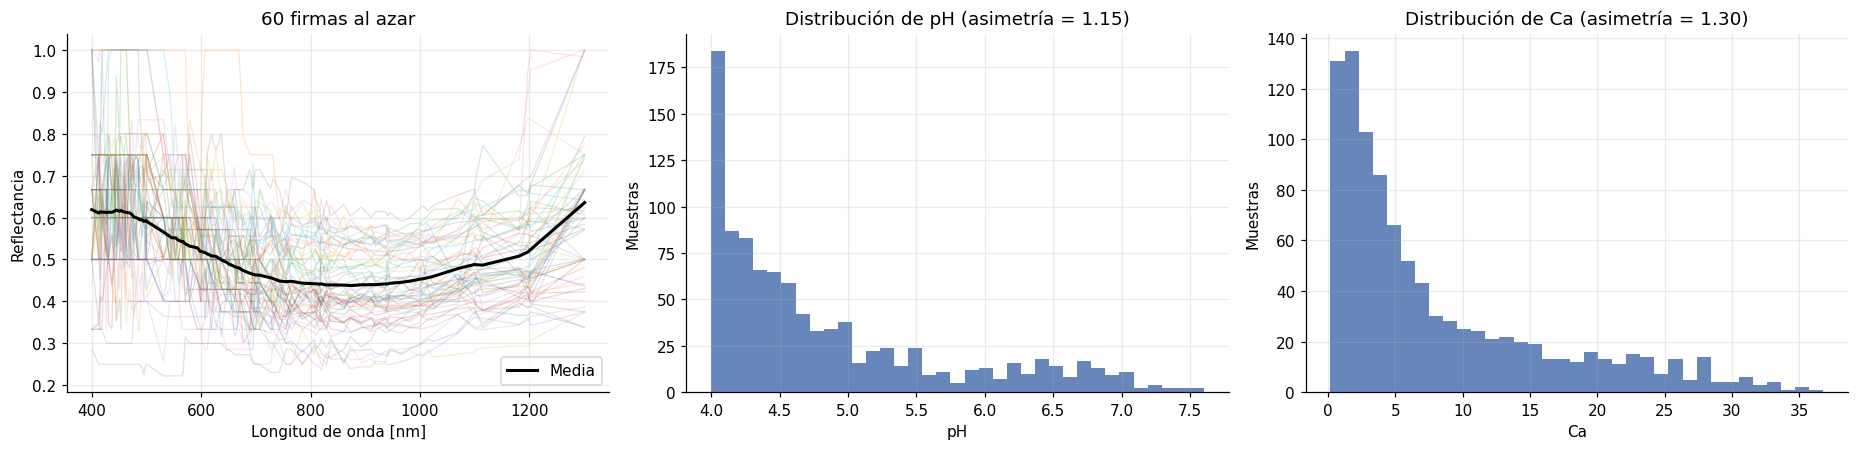

Espaciado entre bandas [nm]: mín 2.0 | máx 98.0


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
rng = np.random.default_rng(RANDOM_STATE)
for i in rng.choice(len(X_raw), size=min(60, len(X_raw)), replace=False):
    axes[0].plot(wavelengths, X_raw[i], alpha=0.2, lw=0.8)
axes[0].plot(wavelengths, X_raw.mean(0), color="k", lw=2, label="Media")
axes[0].set_xlabel("Longitud de onda [nm]")
axes[0].set_ylabel("Reflectancia")
axes[0].set_title("60 firmas al azar")
axes[0].legend()

for ax, t in zip(axes[1:], TARGETS):
    ax.hist(Y[t], bins=35, color="#4C72B0", alpha=0.85)
    ax.set_xlabel(t)
    ax.set_ylabel("Muestras")
    ax.set_title(f"Distribución de {t} (asimetría = {pd.Series(Y[t]).skew():.2f})")
plt.tight_layout()
savefig("05_firmas_y_targets")
plt.show()

print("Espaciado entre bandas [nm]: mín", np.diff(wavelengths).min(), "| máx", np.diff(wavelengths).max())

# 6. Preprocesamientos

Se usan los 4 preprocesamientos que mejor funcionaron: `RAW`, `SG`, `ABS` y `ABS+SG`:

| Paso | Descripción |
|---|---|
| `RAW` | Reflectancia sin cambios |
| `SG` | Suavizado Savitzky–Golay a lo largo del espectro (ventana 11, orden 2) |
| `ABS` | Absorbancia `log10(1/R)`, que linealiza la relación con la concentración (Beer–Lambert) |
| `ABS+SG` | Absorbancia y luego suavizado |

En la CNN 3D el preprocesamiento se aplica al espectro de cada píxel del cubo reducido.

In [9]:
def repair_nonpositive(X, wl):
    """Interpola, dentro de cada firma, los valores R <= 0 (evita log(0))."""
    X = np.array(X, dtype=np.float64, copy=True)
    for i in range(X.shape[0]):
        bad = ~np.isfinite(X[i]) | (X[i] <= 0)
        if bad.any():
            good = ~bad
            if good.sum() < 2:
                raise ValueError(f"La firma {i} no tiene valores válidos suficientes.")
            X[i, bad] = np.interp(wl[bad], wl[good], X[i, good])
    return X


def snv(X):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True)
    return (X - mu) / (sd + 1e-12)


def upper_hull(x, y):
    """Envolvente convexa superior (cadena monótona de Andrew)."""
    hull = []
    for p in zip(x, y):
        while len(hull) >= 2:
            (x1, y1), (x2, y2) = hull[-2], hull[-1]
            if (x2 - x1) * (p[1] - y1) - (y2 - y1) * (p[0] - x1) >= 0:
                hull.pop()
            else:
                break
        hull.append(p)
    hx, hy = zip(*hull)
    return np.interp(x, hx, hy)


def continuum_removal(X, wl):
    X = repair_nonpositive(X, wl)
    return np.vstack([r / upper_hull(wl, r) for r in X])


class SpectralPreprocessor(BaseEstimator, TransformerMixin):
    """Aplica una cadena de pasos, p. ej. 'ABS+SG+SNV'. Solo MSC aprende algo en fit()."""

    STEPS = {"RAW", "SG", "SNV", "MSC", "ABS", "D1", "CR"}

    def __init__(self, mode="RAW", wavelengths=None):
        self.mode = mode
        self.wavelengths = wavelengths

    def _steps(self):
        steps = [s.strip().upper() for s in self.mode.split("+")]
        unknown = set(steps) - self.STEPS
        if unknown:
            raise ValueError(f"Pasos desconocidos en '{self.mode}': {unknown}")
        return steps

    def _run(self, X, fitting):
        wl = np.asarray(self.wavelengths, dtype=float)
        X = np.asarray(X, dtype=np.float64)
        for k, step in enumerate(self._steps()):
            if step == "RAW":
                continue
            elif step == "SG":
                X = savgol_filter(X, SG_WINDOW, SG_POLYORDER, axis=1, mode="interp")
            elif step == "SNV":
                X = snv(X)
            elif step == "ABS":
                X = np.log10(1.0 / repair_nonpositive(X, wl))
            elif step == "D1":
                X = np.gradient(X, wl, axis=1, edge_order=2) * 100.0   # por cada 100 nm
            elif step == "CR":
                X = continuum_removal(X, wl)
            elif step == "MSC":
                if fitting:
                    self.msc_ref_ = X.mean(axis=0)
                ref = self.msc_ref_
                A = np.vstack([np.ones_like(ref), ref]).T
                coef, *_ = np.linalg.lstsq(A, X.T, rcond=None)      # (2, n)
                X = (X - coef[0][:, None]) / (coef[1][:, None] + 1e-12)
        return X

    def fit(self, X, y=None):
        self._run(X, fitting=True)
        return self

    def transform(self, X):
        return self._run(X, fitting=False)


def preprocess_fold(mode, X_train, *others):
    """Ajusta el preprocesamiento con X_train y lo aplica a los demás conjuntos."""
    prep = SpectralPreprocessor(mode, wavelengths).fit(X_train)
    return [prep.transform(X_train)] + [prep.transform(X) for X in others]


def _cube_pixels(C):
    # (N, B, S, S) -> (N*S*S, B)
    return np.moveaxis(np.asarray(C, dtype=np.float64), 1, -1).reshape(-1, C.shape[1])


def preprocess_cubes(mode, C_train, *others):
    """Mismo preprocesamiento, aplicado al espectro de cada píxel de los cubos reducidos."""
    prep = SpectralPreprocessor(mode, wavelengths).fit(_cube_pixels(C_train))
    out = []
    for C in (C_train,) + others:
        Z = prep.transform(_cube_pixels(C)).reshape(C.shape[0], C.shape[2], C.shape[3], C.shape[1])
        out.append(np.moveaxis(Z, -1, 1).astype(np.float32))
    return out, prep

# 7. Partición: 10 % de test congelado + 5 folds sobre el 90 % restante

La estratificación combina cuartiles de pH y de Ca, para que el test y cada fold tengan distribuciones parecidas de ambos targets.

In [10]:
def joint_strata(frame, q):
    a = pd.qcut(frame["pH"].rank(method="first"), q, labels=False)
    b = pd.qcut(frame["Ca"].rank(method="first"), q, labels=False)
    return (a.astype(str) + "_" + b.astype(str)).to_numpy()


def safe_strata(frame, q, min_count):
    """Baja el número de cuantiles hasta que todos los estratos tengan min_count muestras."""
    for qq in range(q, 1, -1):
        s = joint_strata(frame, qq)
        if pd.Series(s).value_counts().min() >= min_count:
            return s, qq
    return np.zeros(len(frame), dtype=int), 1


all_idx = np.arange(len(df))
strata_all, q_used = safe_strata(df, STRATIFY_BINS, min_count=N_FOLDS + 2)
dev_idx, test_idx = train_test_split(
    all_idx, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=strata_all
)
dev_idx = np.sort(dev_idx)
test_idx = np.sort(test_idx)

strata_dev, _ = safe_strata(df.iloc[dev_idx].reset_index(drop=True), STRATIFY_BINS, min_count=N_FOLDS)
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
FOLDS = [(dev_idx[tr], dev_idx[va]) for tr, va in skf.split(dev_idx, strata_dev)]

fold_of = np.full(len(df), -1)
for k, (_, va) in enumerate(FOLDS):
    fold_of[va] = k

assert len(set(dev_idx) & set(test_idx)) == 0
assert np.all(np.sort(np.concatenate([va for _, va in FOLDS])) == dev_idx)

split_df = df[["Numero"] + TARGETS].copy()
split_df["conjunto"] = "desarrollo"
split_df.loc[test_idx, "conjunto"] = "test"
split_df["fold"] = fold_of
split_df.to_csv(TABLE_DIR / "particion.csv", index=False)

print(f"Desarrollo: {len(dev_idx)} | Test: {len(test_idx)} | Folds: {N_FOLDS} (cuantiles usados: {q_used})")
display(split_df.groupby("conjunto")[TARGETS].agg(["count", "mean", "std", "min", "max"]).round(2))
display(split_df[split_df.fold >= 0].groupby("fold")[TARGETS].agg(["count", "mean", "std"]).round(2))

Desarrollo: 878 | Test: 98 | Folds: 5 (cuantiles usados: 2)


pH                          Ca                        
           count  mean   std  min  max count  mean   std   min   max
conjunto                                                            
desarrollo   878  4.86  0.86  4.0  7.6   878  8.18  8.11  0.18  36.8
test          98  4.90  0.86  4.0  7.3    98  8.27  8.16  0.26  30.7

pH                Ca            
     count  mean   std count  mean   std
fold                                    
0      176  4.90  0.88   176  8.54  8.21
1      176  4.84  0.86   176  8.16  8.49
2      176  4.92  0.91   176  8.47  8.55
3      175  4.82  0.83   175  7.71  7.56
4      175  4.81  0.82   175  8.01  7.74

# 8. Métricas, transformación del target y bootstrap

- **RMSE, MAE**: error en las unidades del target.
- **R²**: fracción de la varianza explicada (0 = igual que predecir la media).
- **Bias**: error medio (predicción − real).
- **RPD** = desviación estándar / RMSE; **RPIQ** = rango intercuartílico / RMSE. En espectroscopía de suelos, RPD < 1.4 se considera poco confiable, 1.4–2 aceptable y > 2 bueno.
- **Bootstrap**: el test tiene solo 98 muestras, así que cualquier métrica en test trae incertidumbre. Remuestreando el test 2000 veces se obtiene un intervalo del 95 % para R² y RMSE.

In [11]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    q75, q25 = np.percentile(y_true, [75, 25])
    return {
        "RMSE": rmse,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
        "Bias": float(np.mean(y_pred - y_true)),
        "RPD": float(np.std(y_true, ddof=1) / rmse) if rmse > 0 else np.inf,
        "RPIQ": float((q75 - q25) / rmse) if rmse > 0 else np.inf,
    }


class TargetScaler(BaseEstimator, TransformerMixin):
    """Transformación del target: identity o log1p, seguida de estandarización."""

    def __init__(self, kind="identity"):
        self.kind = kind

    def _f(self, y):
        return np.log1p(y) if self.kind == "log1p" else y

    def _finv(self, z):
        return np.expm1(z) if self.kind == "log1p" else z

    def fit(self, y, yy=None):
        z = self._f(np.asarray(y, dtype=float).reshape(-1, 1))
        self.mu_ = float(z.mean())
        self.sd_ = float(z.std()) or 1.0
        return self

    def transform(self, y):
        return (self._f(np.asarray(y, dtype=float).reshape(-1, 1)) - self.mu_) / self.sd_

    def inverse_transform(self, z):
        return self._finv(np.asarray(z, dtype=float).reshape(-1, 1) * self.sd_ + self.mu_)


def bootstrap_ci(y_true, y_pred, n_boot=N_BOOTSTRAP, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    r2s, rmses = [], []
    for _ in range(n_boot):
        b = rng.integers(0, len(y_true), len(y_true))
        if np.std(y_true[b]) == 0:
            continue
        r2s.append(r2_score(y_true[b], y_pred[b]))
        rmses.append(np.sqrt(mean_squared_error(y_true[b], y_pred[b])))
    return {
        "R2_IC95": (float(np.percentile(r2s, 2.5)), float(np.percentile(r2s, 97.5))),
        "RMSE_IC95": (float(np.percentile(rmses, 2.5)), float(np.percentile(rmses, 97.5))),
    }


def prob_better(y_true, pred_a, pred_b, n_boot=N_BOOTSTRAP, seed=RANDOM_STATE):
    """Fracción de remuestreos bootstrap del test en que A tiene menor RMSE que B."""
    rng = np.random.default_rng(seed)
    y_true, pred_a, pred_b = map(lambda v: np.asarray(v, dtype=float), (y_true, pred_a, pred_b))
    wins = 0
    for _ in range(n_boot):
        b = rng.integers(0, len(y_true), len(y_true))
        wins += np.mean((pred_a[b] - y_true[b]) ** 2) < np.mean((pred_b[b] - y_true[b]) ** 2)
    return wins / n_boot


def parity_ax(ax, y_true, y_pred, title):
    lo = min(np.min(y_true), np.min(y_pred))
    hi = max(np.max(y_true), np.max(y_pred))
    ax.scatter(y_true, y_pred, s=18, alpha=0.7)
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    m = regression_metrics(y_true, y_pred)
    ax.set_title(f"{title}\nR²={m['R2']:.3f}  RMSE={m['RMSE']:.3f}  RPD={m['RPD']:.2f}", fontsize=10)
    ax.set_xlabel("Real")
    ax.set_ylabel("Predicho")

# 9. Relación banda–target (solo con datos de desarrollo)

Correlación de Pearson entre cada banda y el target, para cada preprocesamiento. Da una idea de cuánta señal lineal hay y en qué parte del espectro. Se calcula solo con el 90 % de desarrollo para no mirar el test.

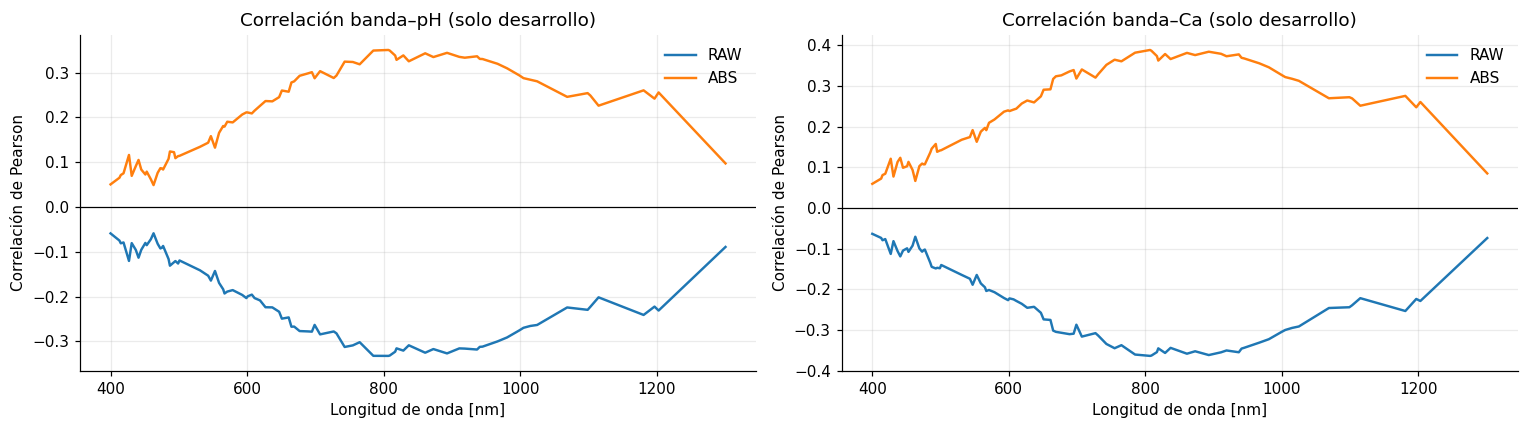

target,Ca,pH
preproceso,,
ABS,0.389,0.350
ABS+SG,0.389,0.351
RAW,0.363,0.332
SG,0.365,0.334


In [12]:
def band_correlations(X, y):
    Xc = X - X.mean(0)
    yc = y - y.mean()
    den = np.sqrt((Xc ** 2).sum(0) * (yc ** 2).sum())
    with np.errstate(invalid="ignore", divide="ignore"):
        return (Xc * yc[:, None]).sum(0) / den


corr_summary, corr_curves = [], {}
for t in TARGETS:
    for mode in PREPROCESS_CANDIDATES:
        Xp = SpectralPreprocessor(mode, wavelengths).fit_transform(X_raw[dev_idx])
        r = band_correlations(Xp, Y[t][dev_idx])
        corr_curves[(t, mode)] = r
        corr_summary.append({"target": t, "preproceso": mode, "max_|r|": float(np.nanmax(np.abs(r))),
                             "λ_max_|r|": float(wavelengths[np.nanargmax(np.abs(r))])})

show_modes = [m for m in ["RAW", "ABS", "SG+SNV"] if m in PREPROCESS_CANDIDATES]
fig, axes = plt.subplots(1, len(TARGETS), figsize=(7 * len(TARGETS), 4), squeeze=False)
for ax, t in zip(axes[0], TARGETS):
    for mode in show_modes:
        ax.plot(wavelengths, corr_curves[(t, mode)], lw=1.6, label=mode)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel("Longitud de onda [nm]")
    ax.set_ylabel("Correlación de Pearson")
    ax.set_title(f"Correlación banda–{t} (solo desarrollo)")
    ax.legend(frameon=False)
plt.tight_layout()
savefig("09_correlacion_banda_target")
plt.show()

corr_df = pd.DataFrame(corr_summary)
display(corr_df.pivot(index="preproceso", columns="target", values="max_|r|").round(3))
corr_df.to_csv(TABLE_DIR / "correlacion_maxima_por_preproceso.csv", index=False)

# 10. Modelos clásicos

Se prueban PLSR, Ridge, SVR (kernel RBF) y Random Forest con dos entradas:

| Entrada | Descripción | Contra qué CNN se compara |
|---|---|---|
| Firma `.MAT` (84) | La firma de cada archivo `.MAT` | CNN 1D (misma entrada) |
| Cubo: media + desv. por banda (168) | Promedio y desviación estándar de los 400 píxeles del cubo reducido: resume el espectro y su variación espacial | CNN 3D (misma fuente: el cubo) |

Los métodos clásicos no pueden recibir un cubo directamente (solo aceptan un vector por muestra); por eso reciben este resumen del mismo cubo que usa la CNN 3D, con el mismo preprocesamiento aplicado a cada píxel.

Para cada entrada, preprocesamiento, transformación del target y combinación de hiperparámetros se obtiene una predicción fuera de muestra para las 878 muestras de desarrollo (cada muestra la predice el modelo del fold donde fue validación). Con esas predicciones se calcula el R2 de validación cruzada, que es el criterio para elegir todo. El ganador de cada modelo se reentrena con todo el desarrollo y predice el test una sola vez.

In [13]:
def make_classical(name, params, target_transform):
    if name == "PLSR":
        base = PLSRegression(n_components=int(params["n_components"]), scale=False)
    elif name == "Ridge":
        base = Ridge(alpha=float(params["alpha"]))
    elif name == "SVR":
        base = SVR(kernel="rbf", **params)
    elif name == "RF":
        base = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **params)
    else:
        raise ValueError(name)
    return TransformedTargetRegressor(
        regressor=Pipeline([("scaler", StandardScaler()), ("model", base)]),
        transformer=TargetScaler(target_transform),
        check_inverse=False,
    )


def classical_grid(n_features):
    grid = [("PLSR", {"n_components": c}) for c in PLS_COMPONENTS if c < n_features]
    grid += [("Ridge", {"alpha": a}) for a in RIDGE_ALPHAS]
    grid += [("SVR", dict(p)) for p in SVR_GRID]
    grid += [("RF", dict(p)) for p in RF_GRID]
    return grid


CLASSICAL_MODELS = ["PLSR", "Ridge", "SVR", "RF"]
CLASSICAL_INPUTS = {
    "MAT": ("firma .MAT (84)", ""),
    "CUBE_MEAN_STD": ("cubo: media + desv. por banda (168)", " · cubo media+desv"),
}
if not CLASSICAL_CUBE_INPUTS:
    CLASSICAL_INPUTS = {"MAT": CLASSICAL_INPUTS["MAT"]}
CLASSICAL_NAMES = {inp: [m + sfx for m in CLASSICAL_MODELS] for inp, (_, sfx) in CLASSICAL_INPUTS.items()}


def cube_features(C, chunk=128):
    """(N, bandas, S, S) -> (N, 2*bandas): media y desviación de los píxeles, por banda."""
    out = []
    for i in range(0, len(C), chunk):
        c = np.asarray(C[i:i + chunk], dtype=np.float64)
        out.append(np.hstack([c.mean(axis=(2, 3)), c.std(axis=(2, 3))]))
    return np.vstack(out)


def features(inp, mode, fit_idx, *other_idx):
    """Entrada ya preprocesada. El preprocesamiento se ajusta SOLO con fit_idx (train del fold o desarrollo)."""
    if inp == "MAT":
        return preprocess_fold(mode, X_raw[fit_idx], *[X_raw[i] for i in other_idx])
    cubes, _ = preprocess_cubes(mode, CUBE_RAW[fit_idx], *[CUBE_RAW[i] for i in other_idx])
    return [cube_features(C) for C in cubes]


# Entradas de cada fold (se calculan una vez y sirven para pH y para Ca).
FEAT_CV = {(inp, mode, k): features(inp, mode, tr, va)
           for inp in CLASSICAL_INPUTS for mode in PREPROCESS_CANDIDATES for k, (tr, va) in enumerate(FOLDS)}


def run_classical_cv(target, inp):
    y = Y[target]
    rows = []
    for mode in PREPROCESS_CANDIDATES:
        grid = classical_grid(FEAT_CV[(inp, mode, 0)][0].shape[1])
        for tt in TARGET_TRANSFORMS[target]:
            t0 = time.time()
            oof = np.zeros((len(grid), len(df)))
            for k, (tr, va) in enumerate(FOLDS):
                Xtr, Xva = FEAT_CV[(inp, mode, k)]
                for g, (name, params) in enumerate(grid):
                    model = make_classical(name, params, tt).fit(Xtr, y[tr])
                    oof[g, va] = np.ravel(model.predict(Xva))
            for g, (name, params) in enumerate(grid):
                rows.append({"target": target, "entrada": CLASSICAL_INPUTS[inp][0], "modelo": name,
                             "preproceso": mode, "transformacion": tt, "params": json.dumps(params),
                             **regression_metrics(y[dev_idx], oof[g, dev_idx])})
            print(f"  {target} | {CLASSICAL_INPUTS[inp][0]:36s} | {mode:7s} | {tt:8s} | "
                  f"{len(grid)} configuraciones | {time.time() - t0:5.1f} s")
    return pd.DataFrame(rows)


classical_cv, best_classical = {}, {}
for t in TARGETS:
    for inp, (label, _) in CLASSICAL_INPUTS.items():
        print(f"\n=== Validación cruzada de modelos clásicos: {t} — {label} ===")
        res = run_classical_cv(t, inp)
        classical_cv[(t, inp)] = res
        res.to_csv(TABLE_DIR / f"cv_clasicos_{t}_{inp}.csv", index=False)
        best = (res.sort_values("R2", ascending=False).groupby("modelo", sort=False).head(1)
                .set_index("modelo").loc[CLASSICAL_MODELS].reset_index())
        best_classical[(t, inp)] = best
        print(f"Mejor configuración por modelo (CV) — {t} — {label}")
        display(best[["modelo", "preproceso", "transformacion", "params", "RMSE", "R2", "RPD"]].round(4))
del FEAT_CV


=== Validación cruzada de modelos clásicos: pH — firma .MAT (84) ===
  pH | firma .MAT (84)                      | RAW     | identity | 44 configuraciones |  15.0 s
  pH | firma .MAT (84)                      | SG      | identity | 44 configuraciones |  15.7 s
  pH | firma .MAT (84)                      | ABS     | identity | 44 configuraciones |  14.8 s
  pH | firma .MAT (84)                      | ABS+SG  | identity | 44 configuraciones |  15.9 s
Mejor configuración por modelo (CV) — pH — firma .MAT (84)


,modelo,preproceso,transformacion,params,RMSE,R2,RPD
0,PLSR,ABS+SG,identity,"{""n_components"": 7}",0.8056,0.1196,1.0663
1,Ridge,ABS,identity,"{""alpha"": 316.22776601683796}",0.8013,0.1290,1.0721
2,SVR,ABS+SG,identity,"{""C"": 10.0, ""gamma"": 0.001, ""epsilon"": 0.1}",0.8148,0.0993,1.0543
3,RF,ABS+SG,identity,"{""n_estimators"": 300, ""max_features"": ""sqrt"", ...",0.7935,0.1457,1.0826



=== Validación cruzada de modelos clásicos: pH — cubo: media + desv. por banda (168) ===
  pH | cubo: media + desv. por banda (168)  | RAW     | identity | 44 configuraciones |  16.3 s
  pH | cubo: media + desv. por banda (168)  | SG      | identity | 44 configuraciones |  16.9 s
  pH | cubo: media + desv. por banda (168)  | ABS     | identity | 44 configuraciones |  16.0 s
  pH | cubo: media + desv. por banda (168)  | ABS+SG  | identity | 44 configuraciones |  16.9 s
Mejor configuración por modelo (CV) — pH — cubo: media + desv. por banda (168)


,modelo,preproceso,transformacion,params,RMSE,R2,RPD
0,PLSR,ABS+SG,identity,"{""n_components"": 6}",0.8017,0.1281,1.0716
1,Ridge,ABS,identity,"{""alpha"": 316.22776601683796}",0.7986,0.1349,1.0757
2,SVR,SG,identity,"{""C"": 10.0, ""gamma"": 0.001, ""epsilon"": 0.1}",0.8134,0.1024,1.0561
3,RF,SG,identity,"{""n_estimators"": 300, ""max_features"": ""sqrt"", ...",0.7782,0.1784,1.1038



=== Validación cruzada de modelos clásicos: Ca — firma .MAT (84) ===
  Ca | firma .MAT (84)                      | RAW     | identity | 44 configuraciones |  14.9 s
  Ca | firma .MAT (84)                      | RAW     | log1p    | 44 configuraciones |  14.9 s
  Ca | firma .MAT (84)                      | SG      | identity | 44 configuraciones |  15.6 s
  Ca | firma .MAT (84)                      | SG      | log1p    | 44 configuraciones |  15.9 s
  Ca | firma .MAT (84)                      | ABS     | identity | 44 configuraciones |  15.2 s
  Ca | firma .MAT (84)                      | ABS     | log1p    | 44 configuraciones |  15.1 s
  Ca | firma .MAT (84)                      | ABS+SG  | identity | 44 configuraciones |  15.5 s
  Ca | firma .MAT (84)                      | ABS+SG  | log1p    | 44 configuraciones |  15.1 s
Mejor configuración por modelo (CV) — Ca — firma .MAT (84)


,modelo,preproceso,transformacion,params,RMSE,R2,RPD
0,PLSR,ABS+SG,identity,"{""n_components"": 11}",7.4231,0.1607,1.0922
1,Ridge,ABS+SG,identity,"{""alpha"": 31.622776601683793}",7.4007,0.1658,1.0955
2,SVR,ABS,identity,"{""C"": 10.0, ""gamma"": 0.001, ""epsilon"": 0.1}",7.4961,0.1441,1.0815
3,RF,SG,identity,"{""n_estimators"": 300, ""max_features"": ""sqrt"", ...",7.3713,0.1724,1.0998



=== Validación cruzada de modelos clásicos: Ca — cubo: media + desv. por banda (168) ===
  Ca | cubo: media + desv. por banda (168)  | RAW     | identity | 44 configuraciones |  16.7 s
  Ca | cubo: media + desv. por banda (168)  | RAW     | log1p    | 44 configuraciones |  16.2 s
  Ca | cubo: media + desv. por banda (168)  | SG      | identity | 44 configuraciones |  17.2 s
  Ca | cubo: media + desv. por banda (168)  | SG      | log1p    | 44 configuraciones |  17.3 s
  Ca | cubo: media + desv. por banda (168)  | ABS     | identity | 44 configuraciones |  16.6 s
  Ca | cubo: media + desv. por banda (168)  | ABS     | log1p    | 44 configuraciones |  16.2 s
  Ca | cubo: media + desv. por banda (168)  | ABS+SG  | identity | 44 configuraciones |  17.4 s
  Ca | cubo: media + desv. por banda (168)  | ABS+SG  | log1p    | 44 configuraciones |  17.1 s
Mejor configuración por modelo (CV) — Ca — cubo: media + desv. por banda (168)


,modelo,preproceso,transformacion,params,RMSE,R2,RPD
0,PLSR,ABS+SG,identity,"{""n_components"": 6}",7.4180,0.1619,1.0929
1,Ridge,ABS+SG,identity,"{""alpha"": 100.0}",7.4004,0.1658,1.0955
2,SVR,ABS+SG,identity,"{""C"": 10.0, ""gamma"": 0.001, ""epsilon"": 0.1}",7.4935,0.1447,1.0819
3,RF,SG,identity,"{""n_estimators"": 300, ""max_features"": ""sqrt"", ...",7.2136,0.2074,1.1239


In [14]:
# Ajuste final: cada mejor configuración se reentrena con todo el desarrollo (90 %)
# y se evalúa UNA vez en test.
TEST_PRED = {t: {} for t in TARGETS}
CV_METRICS = {t: {} for t in TARGETS}
CONFIG = {t: {} for t in TARGETS}

for t in TARGETS:
    y = Y[t]
    # Referencia: predecir siempre la media del desarrollo.
    TEST_PRED[t]["Media (referencia)"] = np.full(len(test_idx), y[dev_idx].mean())
    CV_METRICS[t]["Media (referencia)"] = {"RMSE": float(np.std(y[dev_idx])), "R2": 0.0}
    CONFIG[t]["Media (referencia)"] = {"input": "-", "preprocess": "-", "target_transform": "-",
                                       "param_name": "-", "param_value": "-"}
    for inp, (label, sfx) in CLASSICAL_INPUTS.items():
        for _, row in best_classical[(t, inp)].iterrows():
            name = row["modelo"] + sfx
            params = json.loads(row["params"])
            Xdev, Xte = features(inp, row["preproceso"], dev_idx, test_idx)
            model = make_classical(row["modelo"], params, row["transformacion"]).fit(Xdev, y[dev_idx])
            TEST_PRED[t][name] = np.ravel(model.predict(Xte))
            CV_METRICS[t][name] = {"RMSE": row["RMSE"], "R2": row["R2"]}
            CONFIG[t][name] = {"input": label, "preprocess": row["preproceso"],
                               "target_transform": row["transformacion"],
                               "param_name": ", ".join(params.keys()),
                               "param_value": ", ".join(f"{v:g}" if isinstance(v, float) else str(v)
                                                        for v in params.values())}
            joblib.dump({"entrada": label, "preproceso": row["preproceso"], "model": model, "wavelengths": wavelengths},
                        MODEL_DIR / f"{t}_{name.replace(' · ', '_').replace(' ', '_')}.joblib")

print("Modelos clásicos ajustados con el 90 % de desarrollo y evaluados en test.")

Modelos clásicos ajustados con el 90 % de desarrollo y evaluados en test.


# 11. Entrada de la CNN 3D: el cubo reducido

Cada muestra entra a la CNN 3D como un cubo de 84 bandas × 20 × 20 píxeles. Cada píxel es el promedio de un bloque de 9 × 9 píxeles del cubo original (solo píxeles de suelo y sin valores defectuosos). A la derecha, el espectro de cada uno de los 400 píxeles: esa variación espacial es lo que la firma no tiene y la CNN 3D puede usar.

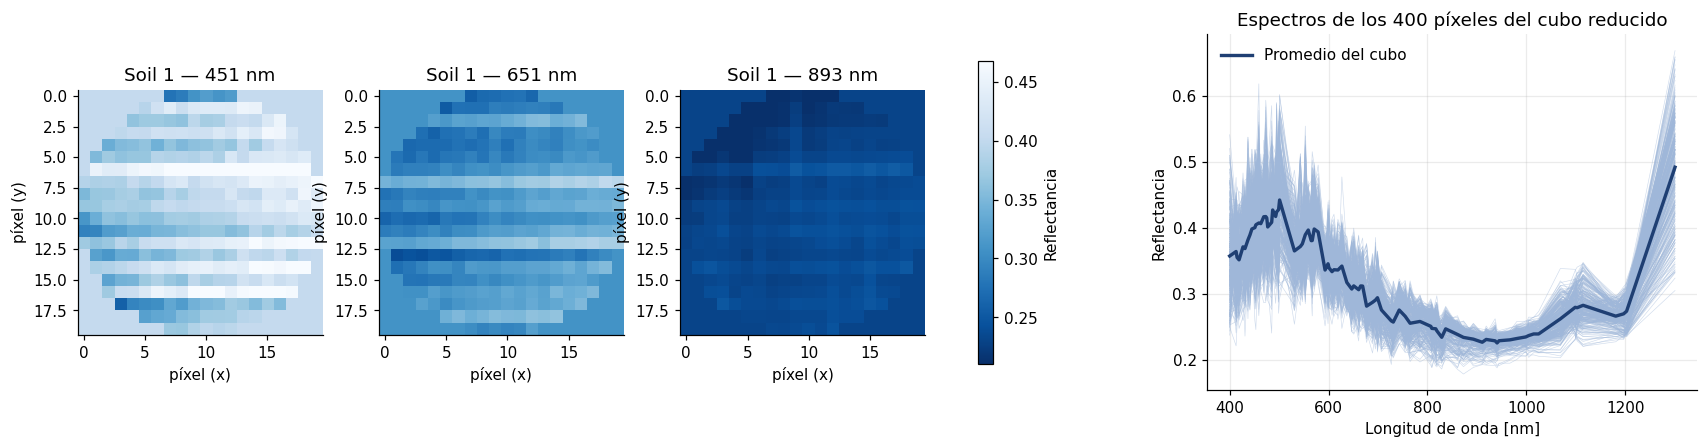

In [15]:
_i = int(dev_idx[0])
_sid = int(df.loc[_i, "Numero"])
_cube = CUBE_RAW[_i]
_bands = [int(np.argmin(np.abs(wavelengths - w))) for w in (450, 650, 900)]
fig, axes = plt.subplots(1, 4, figsize=(19, 4.2), gridspec_kw={"width_ratios": [1, 1, 1, 1.6]})
vmin, vmax = np.percentile(_cube[_bands], [2, 98])
for ax, b in zip(axes[:3], _bands):
    im = ax.imshow(_cube[b], cmap="Blues_r", vmin=vmin, vmax=vmax)
    ax.set_title(f"Soil {_sid} — {wavelengths[b]:.0f} nm")
    ax.set_xlabel("píxel (x)")
    ax.set_ylabel("píxel (y)")
    ax.grid(False)
fig.colorbar(im, ax=axes[:3], shrink=0.85, label="Reflectancia")
axes[3].plot(wavelengths, _cube.reshape(_cube.shape[0], -1), color="#9FB7D9", lw=0.4, alpha=0.5)
axes[3].plot(wavelengths, _cube.reshape(_cube.shape[0], -1).mean(1), color="#1F3F73", lw=2.2, label="Promedio del cubo")
axes[3].set_xlabel("Longitud de onda [nm]")
axes[3].set_ylabel("Reflectancia")
axes[3].set_title("Espectros de los 400 píxeles del cubo reducido")
axes[3].legend(frameon=False)
savefig(f"11_entrada_cnn3d_Soil{_sid}")
plt.show()

# 12. Las dos CNN y su entrenamiento

```
CNN 1D (firma 84)                 CNN 3D (cubo 84×20×20)
firma → estandarizar por banda    cubo → estandarizar por banda
 → Conv1d k7 ×2 → MaxPool          → Conv3d 7×3×3 ×2 → MaxPool3d
 → Conv1d k5 ×2 → MaxPool          → Conv3d 5×3×3   → MaxPool3d
 → Conv1d k3    → MaxPool          → Conv3d 3×3×3   → AvgPool(8,1,1)
 → Flatten → Dense 32 → Dense 1    → Flatten → Dense 32 → Dense 1
```

Cada convolución va seguida de BatchNorm y ReLU; antes de cada capa densa hay Dropout (30 %). Las dos terminan igual: Flatten -> fully connected de 32 neuronas -> fully connected de 1 salida (pH o Ca). Las dos tienen del orden de 30.000–40.000 parámetros.


**Entrenamiento:**

- Igual para las dos CNN y en cada uno de los 5 folds.
- **Loss:** la de `CNN_LOSS` (por defecto `"r2"` = 1 − R². También pueden ser `"mse"` y `"hubber"`), sobre el target estandarizado (y transformado con log1p si la validación cruzada lo escogió para Ca).
- AdamW (lr = 3e-4, weight decay = 1e-2), lotes de 32, gradient clipping = 5, `ReduceLROnPlateau`.
- Entrena con los 4/5 de train del fold y después de cada época mide la loss en el 1/5 de validación. Se guardan los pesos de la época con menor val loss (promedio móvil de 5 épocas, mínimo 10 épocas) y se para tras 30 épocas sin mejorar.
- Aumento de datos solo en train: ganancia, desplazamiento y ruido pequeños. La 3D también rota y voltea el cubo, y en validación/test promedia las 8 rotaciones/espejos.

In [16]:
def set_seed(seed):
    set_numpy_seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class Standardize(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer("mean", torch.as_tensor(np.asarray(mean), dtype=torch.float32))
        self.register_buffer("std", torch.as_tensor(np.asarray(std), dtype=torch.float32))

    def forward(self, x):
        return (x - self.mean) / self.std


class R2Loss(nn.Module):
    """Loss = 1 - R² del lote. Minimizarla es lo mismo que maximizar el R²."""

    def forward(self, pred, target):
        ss_res = ((target - pred) ** 2).sum()
        ss_tot = ((target - target.mean()) ** 2).sum().clamp_min(1e-8)
        return ss_res / ss_tot


def make_loss():
    if CNN_LOSS == "r2":
        return R2Loss()
    if CNN_LOSS == "huber":
        return nn.HuberLoss(delta=1.0)
    return nn.MSELoss()


def loss_value(pred, target):
    """Misma loss que en el entrenamiento, sobre un conjunto completo (para las curvas y el early stopping)."""
    if CNN_LOSS == "r2":
        return float(1.0 - r2_score(target, pred))
    if CNN_LOSS == "huber":
        d = np.abs(pred - target)
        return float(np.mean(np.where(d <= 1.0, 0.5 * d ** 2, d - 0.5)))
    return float(np.mean((pred - target) ** 2))


def _block(conv, bn, cin, cout, k):
    pad = k // 2 if isinstance(k, int) else tuple(s // 2 for s in k)
    return [conv(cin, cout, k, padding=pad), bn(cout), nn.ReLU()]


def _head(n_flat):
    return nn.Sequential(nn.Flatten(), nn.Dropout(CNN_DROPOUT), nn.Linear(n_flat, 32), nn.ReLU(),
                         nn.Dropout(CNN_DROPOUT), nn.Linear(32, 1))


def _flat_size(features, shape):
    was = features.training
    features.eval()
    with torch.no_grad():
        n = features(torch.zeros(1, *shape)).numel()
    features.train(was)
    return n


class CNN1D(nn.Module):
    def __init__(self, n_bands, mean, std, w):
        super().__init__()
        c, b = nn.Conv1d, nn.BatchNorm1d
        self.front = Standardize(mean, std)
        self.features = nn.Sequential(
            *_block(c, b, 1, w, 7), *_block(c, b, w, w, 7), nn.MaxPool1d(2),
            *_block(c, b, w, 2 * w, 5), *_block(c, b, 2 * w, 2 * w, 5), nn.MaxPool1d(2),
            *_block(c, b, 2 * w, 4 * w, 3), nn.MaxPool1d(2))
        self.head = _head(_flat_size(self.features, (1, n_bands)))

    def forward(self, x):                                   # (B, bandas)
        return self.head(self.features(self.front(x).unsqueeze(1))).squeeze(-1)


class CNN3D(nn.Module):
    def __init__(self, n_bands, size, mean, std, w):
        super().__init__()
        c, b = nn.Conv3d, nn.BatchNorm3d
        self.front = Standardize(np.asarray(mean).reshape(-1, 1, 1), np.asarray(std).reshape(-1, 1, 1))
        self.features = nn.Sequential(
            *_block(c, b, 1, w, (7, 3, 3)), *_block(c, b, w, w, (7, 3, 3)), nn.MaxPool3d(2, ceil_mode=True),
            *_block(c, b, w, 2 * w, (5, 3, 3)), nn.MaxPool3d(2, ceil_mode=True),
            *_block(c, b, 2 * w, 4 * w, (3, 3, 3)), nn.AdaptiveAvgPool3d((8, 1, 1)))
        self.head = _head(_flat_size(self.features, (1, n_bands, size, size)))

    def forward(self, x):                                   # (B, bandas, S, S)
        return self.head(self.features(self.front(x).unsqueeze(1))).squeeze(-1)


def build_model(kind, Xtr, spec_cfg=None):
    """Crea la CNN con las estadísticas de normalización de train."""
    Xtr = np.asarray(Xtr, dtype=np.float64)
    w = CNN_WIDTH[kind]
    if kind == "1D":
        m, s = Xtr.mean(0), Xtr.std(0)
        s[s < 1e-8] = 1.0
        return CNN1D(Xtr.shape[1], m, s, w)
    m, s = Xtr.mean(axis=(0, 2, 3)), Xtr.std(axis=(0, 2, 3))
    s[s < 1e-8] = 1.0
    return CNN3D(Xtr.shape[1], Xtr.shape[2], m, s, w)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def dihedral(x, k):
    """Una de las 8 rotaciones/espejos del cubo en los ejes espaciales."""
    x = torch.rot90(x, k % 4, dims=(2, 3))
    return torch.flip(x, dims=(3,)) if k >= 4 else x


def augment(kind, xb, gstd):
    if not CNN_AUGMENT:
        return xb
    if kind == "3D":
        xb = dihedral(xb, int(torch.randint(0, 8, (1,)).item()))
    shape = (xb.shape[0],) + (1,) * (xb.ndim - 1)
    gain = 1.0 + AUG_SCALE * torch.randn(shape, device=xb.device)
    offset = AUG_OFFSET * gstd * torch.randn(shape, device=xb.device)
    return xb * gain + offset + AUG_NOISE * gstd * torch.randn_like(xb)


def predict_tensor(model, X, tta=False, chunk=256):
    model.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(X), chunk):
            xb = X[i:i + chunk]
            out.append(torch.stack([model(dihedral(xb, k)) for k in range(8)]).mean(0) if tta else model(xb))
    return torch.cat(out).cpu().numpy().astype(np.float64)


def train_cnn(kind, Xtr, ytr, Xva, yva, Xte, target_transform, spec_cfg=None, seed=0,
              max_epochs=None, min_epochs=None, patience=None):
    """Entrena una CNN con train, early stopping con validation. Devuelve historia y predicciones."""
    max_epochs = max_epochs or CNN_MAX_EPOCHS
    min_epochs = CNN_MIN_EPOCHS if min_epochs is None else min_epochs
    patience = patience or CNN_PATIENCE
    set_seed(seed)

    tscaler = TargetScaler(target_transform).fit(ytr)
    ztr, zva = tscaler.transform(ytr).ravel(), tscaler.transform(yva).ravel()
    model = build_model(kind, Xtr, spec_cfg).to(DEVICE)
    to_t = lambda a: torch.as_tensor(np.asarray(a, dtype=np.float32), device=DEVICE)
    Xtr_t, Xva_t, Xte_t, ztr_t = to_t(Xtr), to_t(Xva), to_t(Xte), to_t(ztr)
    gstd = float(np.std(Xtr)) or 1.0
    tta = kind == "3D" and CNN_TTA_3D

    opt = torch.optim.AdamW(model.parameters(), lr=CNN_LR, weight_decay=CNN_WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=CNN_LR_FACTOR,
                                                       patience=CNN_LR_PATIENCE, min_lr=CNN_MIN_LR)
    loss_fn = make_loss()
    gen = torch.Generator().manual_seed(seed)

    history, val_losses = [], []
    best_loss, best_epoch, best_state, wait = np.inf, 0, None, 0
    n = len(Xtr_t)
    for epoch in range(1, max_epochs + 1):
        model.train()
        perm = torch.randperm(n, generator=gen).to(DEVICE)
        for i in range(0, n, CNN_BATCH_SIZE):
            b = perm[i:i + CNN_BATCH_SIZE]
            if len(b) < 2:
                continue
            loss = loss_fn(model(augment(kind, Xtr_t[b], gstd)), ztr_t[b])
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()

        p_tr, p_va = predict_tensor(model, Xtr_t), predict_tensor(model, Xva_t)
        tr_loss, va_loss = loss_value(p_tr, ztr), loss_value(p_va, zva)
        val_losses.append(va_loss)
        va_smooth = float(np.mean(val_losses[-CNN_SMOOTH_WINDOW:]))
        history.append({
            "epoch": epoch, "train_loss": tr_loss, "val_loss": va_loss,
            "train_r2": float(r2_score(ytr, tscaler.inverse_transform(p_tr).ravel())),
            "val_r2": float(r2_score(yva, tscaler.inverse_transform(p_va).ravel())),
            "lr": float(opt.param_groups[0]["lr"]),
        })
        sched.step(va_smooth)
        if epoch >= min_epochs:
            if va_smooth < best_loss - 1e-6:
                best_loss, best_epoch, wait = va_smooth, epoch, 0
                best_state = copy.deepcopy(model.state_dict())
            else:
                wait += 1
                if wait >= patience:
                    break

    if best_state is None:
        best_epoch, best_state = epoch, copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)
    return {
        "history": pd.DataFrame(history), "best_epoch": int(best_epoch),
        "val_pred": tscaler.inverse_transform(predict_tensor(model, Xva_t, tta=tta)).ravel(),
        "test_pred": tscaler.inverse_transform(predict_tensor(model, Xte_t, tta=tta)).ravel(),
        "state_dict": {k: v.detach().cpu() for k, v in best_state.items()},
        "n_params": count_params(model),
    }


def save_cnn_models(res, fname):
    """Guarda los pesos de las 5 redes (una por fold) y todo lo necesario para usarlas."""
    torch.save({"kind": res["kind"], "target": res["target"], "preproceso": res["mode"],
                "spec_cfg": res["spec_cfg"], "target_transform": res["target_transform"],
                "state_dicts": res["states"], "best_epochs": res["best_epochs"],
                "wavelengths": wavelengths.tolist()}, MODEL_DIR / f"{fname}.pt")
    joblib.dump({"preprocessors": res["preps"]}, MODEL_DIR / f"{fname}_preproc.joblib")


print("Parámetros entrenables:")
print("  CNN 1D:", count_params(build_model("1D", X_raw[dev_idx])))
print("  CNN 3D:", count_params(build_model("3D", CUBE_RAW[dev_idx[:50]])))

Parámetros entrenables:
  CNN 1D: 36753
  CNN 3D: 32569


### 12.1 Prueba rápida de las dos CNN

Comprueba en segundos que cada red da una salida por muestra y que el entrenamiento corre en la GPU.

In [17]:
_tr, _va, _te = dev_idx[:120], dev_idx[120:160], test_idx[:10]
(Xa, Xb, Xc) = preprocess_fold("RAW", X_raw[_tr], X_raw[_va], X_raw[_te])
(Ca, Cb, Cc), _ = preprocess_cubes("RAW", CUBE_RAW[_tr], CUBE_RAW[_va], CUBE_RAW[_te])
for kind, data, cfg in [("1D", (Xa, Xb, Xc), None), ("3D", (Ca, Cb, Cc), None)]:
    r = train_cnn(kind, data[0], Y["pH"][_tr], data[1], Y["pH"][_va], data[2], "identity", cfg,
                  max_epochs=3, min_epochs=1, patience=5)
    assert len(r["history"]) == 3 and r["val_pred"].shape == (40,) and r["test_pred"].shape == (10,)

_m = build_model("3D", Ca).to(DEVICE)
print("Los pesos de las CNN están en:", next(_m.parameters()).device)
print("OK: las dos CNN dan una salida por muestra y el entrenamiento corre.")

Los pesos de las CNN están en: cuda:0
OK: las dos CNN dan una salida por muestra y el entrenamiento corre.


# 13. Las dos CNN: selección por validación cruzada

Para cada configuración se entrenan 5 redes (una por fold). Cada muestra del desarrollo recibe la predicción de la red que no la vio al entrenar, y con esas 878 predicciones se calculan `val_RMSE` y `val_R2`. Gana la configuración con menor RMSE de validación cruzada.

Configuraciones que se prueban:

- **CNN 1D:** 4 preprocesamientos.
- **CNN 3D:** 4 preprocesamientos.

Recordar que apra el test, las 5 redes de la configuración ganadora se promedian (ensemble).

In [18]:
C_TRAIN, C_VAL = "#1f77b4", "#d62728"
INPUT_NAME = {"1D": "firma .MAT (84)", "3D": f"cubo 84x{CUBE3D_SIZE}x{CUBE3D_SIZE}"}
CNN_LABEL = {"1D": "CNN_1D", "3D": "CNN_3D"}


def resolve_cnn_transform(target):
    if CNN_TARGET_TRANSFORM != "auto":
        return CNN_TARGET_TRANSFORM
    # La transformación del target que mejor le fue a los clásicos con la firma .MAT (validación cruzada).
    return classical_cv[(target, "MAT")].sort_values("R2", ascending=False).iloc[0]["transformacion"]


def run_cnn_cv(kind, target, mode, spec_cfg=None):
    y = Y[target]
    tt = resolve_cnn_transform(target)
    oof = np.full(len(df), np.nan)
    out = {"kind": kind, "target": target, "mode": mode, "spec_cfg": spec_cfg, "target_transform": tt,
           "histories": [], "best_epochs": [], "test_preds": [], "states": [], "preps": []}
    t0 = time.time()
    for k, (tr, va) in enumerate(FOLDS):
        if kind == "3D":
            (Xtr, Xva, Xte), prep = preprocess_cubes(mode, CUBE_RAW[tr], CUBE_RAW[va], CUBE_RAW[test_idx])
        else:
            prep = SpectralPreprocessor(mode, wavelengths).fit(X_raw[tr])
            Xtr, Xva, Xte = (prep.transform(X_raw[i]) for i in (tr, va, test_idx))
        r = train_cnn(kind, Xtr, y[tr], Xva, y[va], Xte, tt, spec_cfg, seed=RANDOM_STATE + k)
        oof[va] = r["val_pred"]
        out["histories"].append(r["history"].assign(fold=k))
        out["best_epochs"].append(r["best_epoch"])
        out["test_preds"].append(r["test_pred"])
        out["states"].append(r["state_dict"])
        out["preps"].append(prep)
    out["oof"] = oof
    out["cv"] = regression_metrics(y[dev_idx], oof[dev_idx])
    out["test_pred"] = np.mean(out["test_preds"], axis=0)       # ensemble de los 5 folds
    out["minutes"] = (time.time() - t0) / 60
    cfg = "" if spec_cfg is None else f" block={spec_cfg[0]:2d} hop={spec_cfg[1]}"
    print(f"  CNN {kind} | {target} | {mode:7s}{cfg} | {tt:8s} | val RMSE={out['cv']['RMSE']:.4f} "
          f"val R²={out['cv']['R2']:.3f} | épocas={out['best_epochs']} | {out['minutes']:.1f} min")
    return out


def cv_table(results):
    rows = [{"target": r["target"], "preproceso": r["mode"], "transformacion": r["target_transform"],
             "mejor_epoca_mediana": float(np.median(r["best_epochs"])), **r["cv"]} for r in results]
    return pd.DataFrame(rows).sort_values("R2", ascending=False).reset_index(drop=True)


def plot_learning_curves(res, name):
    """Loss (train y validación) y R² vs. épocas. Línea fina = cada fold; gruesa = promedio de los folds."""
    H = pd.concat(res["histories"], ignore_index=True)
    # El promedio se dibuja SOLO mientras los 5 folds siguen entrenando (si no, la línea "salta"
    # cada vez que un fold se detiene).
    M = H.groupby("epoch").mean(numeric_only=True)
    active = H.groupby("epoch")["fold"].nunique()
    M = M[active == H["fold"].nunique()]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    for _, h in H.groupby("fold"):
        axes[0].plot(h.epoch, h.train_loss, color=C_TRAIN, alpha=0.18, lw=0.8)
        axes[0].plot(h.epoch, h.val_loss, color=C_VAL, alpha=0.18, lw=0.8)
        axes[1].plot(h.epoch, h.train_r2, color=C_TRAIN, alpha=0.18, lw=0.8)
        axes[1].plot(h.epoch, h.val_r2, color=C_VAL, alpha=0.18, lw=0.8)
    axes[0].plot(M.index, M.train_loss, color=C_TRAIN, lw=2.2, label="Train loss (promedio 5 folds)")
    axes[0].plot(M.index, M.val_loss, color=C_VAL, lw=2.2, label="Validation loss (promedio 5 folds)")
    axes[1].plot(M.index, M.train_r2, color=C_TRAIN, lw=2.2, label="R² train (promedio 5 folds)")
    axes[1].plot(M.index, M.val_r2, color=C_VAL, lw=2.2, label="R² validación (promedio 5 folds)")

    best = float(np.median(res["best_epochs"]))
    for ax in axes:
        ax.axvline(best, color="k", ls="--", lw=1.2, label=f"Mejor época (mediana) = {best:.0f}")
        ax.set_xlabel("Época")
        ax.legend(fontsize=9, frameon=False)
    axes[0].set_ylabel({"r2": "Loss = 1 − R²", "mse": "Loss (MSE, target estandarizado)"}.get(CNN_LOSS, f"Loss ({CNN_LOSS})"))
    axes[0].set_title("Curvas de loss: train vs. validación")
    axes[1].set_ylabel("R²")
    lo = np.nanpercentile(H[["train_r2", "val_r2"]].values, 5)
    axes[1].set_ylim(max(-0.5, min(0.0, lo)), 1.0)
    axes[1].axhline(0, color="gray", lw=0.8)
    axes[1].set_title("R² vs. épocas")

    cfg = "" if res["spec_cfg"] is None else f" | block={res['spec_cfg'][0]}, hop={res['spec_cfg'][1]}"
    fig.suptitle(f"CNN {res['kind']} — {res['target']} — {res['mode']}{cfg} — "
                 f"val R²={res['cv']['R2']:.3f}, val RMSE={res['cv']['RMSE']:.3f}", y=1.02)
    plt.tight_layout()
    savefig(name)
    plt.show()


def register_cnn(res):
    t, kind = res["target"], res["kind"]
    label = CNN_LABEL[kind]
    TEST_PRED[t][label] = res["test_pred"]
    CV_METRICS[t][label] = {"RMSE": res["cv"]["RMSE"], "R2": res["cv"]["R2"]}
    pname, pval = "épocas (mediana)", f"{np.median(res['best_epochs']):.0f}"
    CONFIG[t][label] = {"input": INPUT_NAME[kind], "preprocess": res["mode"],
                        "target_transform": res["target_transform"], "param_name": pname, "param_value": pval}


CNN_RESULTS = {k: {} for k in ("1D", "3D")}
CNN_BEST = {k: {} for k in ("1D", "3D")}
print("Loss de las CNN:", CNN_LOSS)

Loss de las CNN: r2


### CNN 1D (firma `.MAT` de 84 bandas)

Tabla de validación cruzada de cada configuración y, abajo, las curvas de la ganadora: loss de train/validación y R² vs. épocas (línea fina = cada fold; gruesa = promedio; punteada = mejor época).


=== CNN 1D — pH ===
  CNN 1D | pH | RAW     | identity | val RMSE=0.8176 val R²=0.093 | épocas=[16, 10, 11, 10, 10] | 1.2 min
  CNN 1D | pH | SG      | identity | val RMSE=0.8005 val R²=0.131 | épocas=[11, 10, 18, 17, 10] | 1.2 min
  CNN 1D | pH | ABS     | identity | val RMSE=0.8027 val R²=0.126 | épocas=[11, 10, 28, 15, 10] | 1.3 min
  CNN 1D | pH | ABS+SG  | identity | val RMSE=0.7956 val R²=0.141 | épocas=[11, 10, 16, 26, 10] | 1.2 min


,target,preproceso,transformacion,mejor_epoca_mediana,RMSE,MAE,R2,Bias,RPD,RPIQ
0,pH,ABS+SG,identity,11.0,0.7956,0.6258,0.1413,-0.0395,1.0797,1.3826
1,pH,SG,identity,11.0,0.8005,0.6232,0.1308,-0.0113,1.0732,1.3742
2,pH,ABS,identity,11.0,0.8027,0.6326,0.1260,-0.0057,1.0703,1.3704
3,pH,RAW,identity,10.0,0.8176,0.6325,0.0931,-0.0376,1.0507,1.3454


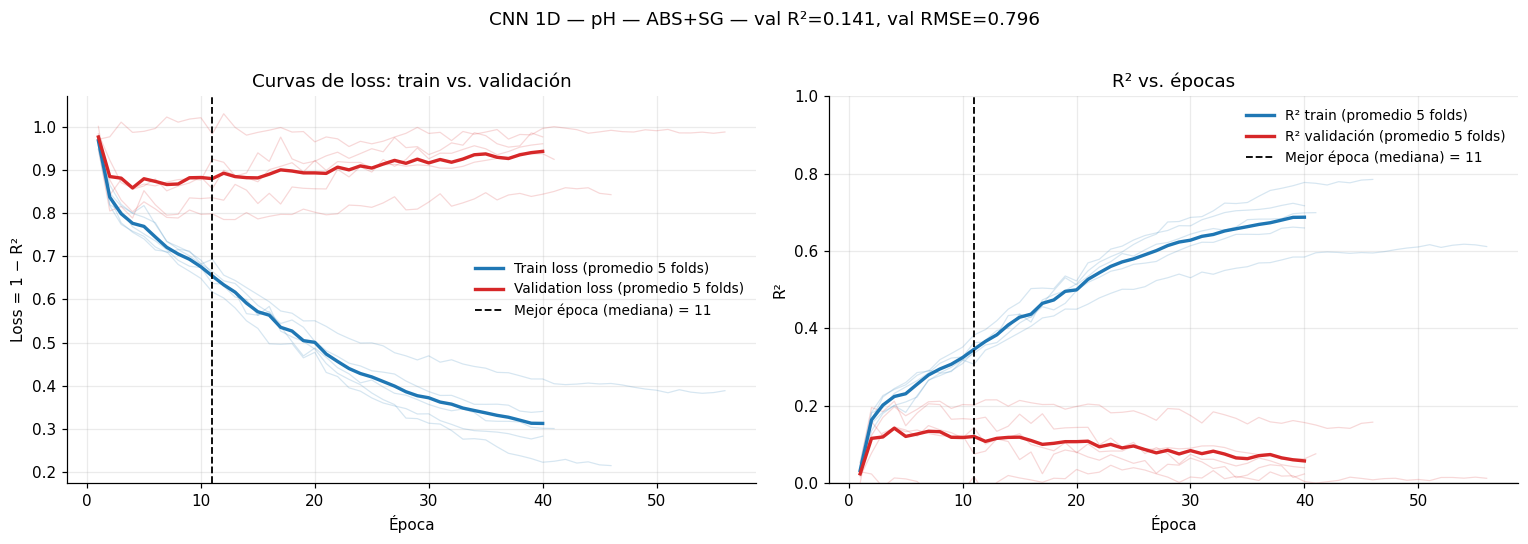


=== CNN 1D — Ca ===
  CNN 1D | Ca | RAW     | identity | val RMSE=7.5279 val R²=0.137 | épocas=[10, 10, 10, 10, 10] | 1.1 min
  CNN 1D | Ca | SG      | identity | val RMSE=7.3812 val R²=0.170 | épocas=[16, 10, 18, 23, 11] | 1.3 min
  CNN 1D | Ca | ABS     | identity | val RMSE=7.4802 val R²=0.148 | épocas=[10, 10, 21, 15, 10] | 1.2 min
  CNN 1D | Ca | ABS+SG  | identity | val RMSE=7.4105 val R²=0.164 | épocas=[18, 10, 15, 17, 10] | 1.2 min


,target,preproceso,transformacion,mejor_epoca_mediana,RMSE,MAE,R2,Bias,RPD,RPIQ
0,Ca,SG,identity,16.0,7.3812,5.6694,0.1702,-0.0683,1.0984,1.3264
1,Ca,ABS+SG,identity,15.0,7.4105,5.7087,0.1636,-0.2116,1.0940,1.3211
2,Ca,ABS,identity,10.0,7.4802,5.7688,0.1477,-0.5062,1.0838,1.3088
3,Ca,RAW,identity,10.0,7.5279,5.7888,0.1368,-0.3634,1.0770,1.3005


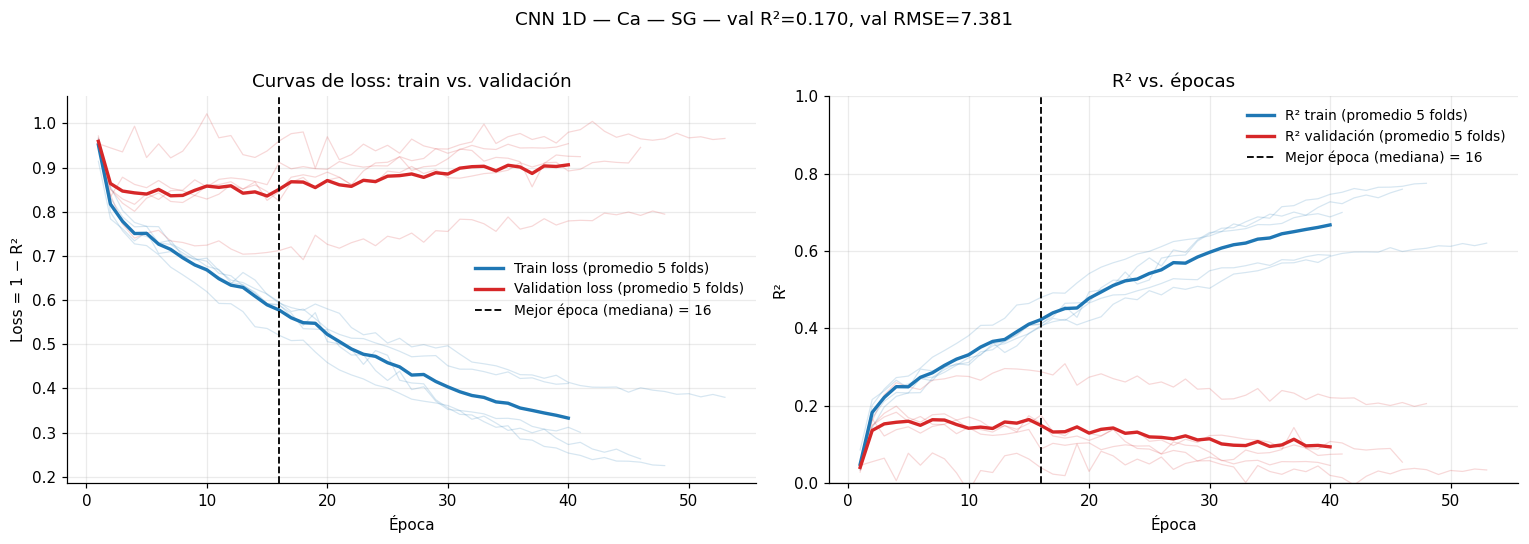

In [19]:
if RUN_CNN_1D:
    for t in TARGETS:
        print(f"\n=== CNN 1D — {t} ===")
        results = [run_cnn_cv("1D", t, mode) for mode in CNN_PREPROCESS_CANDIDATES]
        CNN_RESULTS["1D"][t] = results
        table = cv_table(results)
        table.to_csv(TABLE_DIR / f"cv_cnn1d_{t}.csv", index=False)
        display(table.round(4))
        best = max(results, key=lambda r: r["cv"]["R2"])
        CNN_BEST["1D"][t] = best
        register_cnn(best)
        save_cnn_models(best, f"{t}_CNN1D")
        pd.concat(best["histories"]).to_csv(TABLE_DIR / f"historia_cnn1d_{t}.csv", index=False)
        plot_learning_curves(best, f"14_cnn1d_curvas_{t}")

### CNN 3D (cubo 84 × 20 × 20)

Tabla de validación cruzada de cada configuración y, abajo, las curvas de la ganadora: loss de train/validación y R² vs. épocas (línea fina = cada fold; gruesa = promedio; punteada = mejor época).


=== CNN 3D — pH ===
  CNN 3D | pH | RAW     | identity | val RMSE=0.7798 val R²=0.175 | épocas=[37, 27, 37, 44, 34] | 4.3 min
  CNN 3D | pH | SG      | identity | val RMSE=0.7798 val R²=0.175 | épocas=[22, 96, 47, 46, 36] | 5.2 min
  CNN 3D | pH | ABS     | identity | val RMSE=0.7866 val R²=0.161 | épocas=[35, 11, 34, 18, 21] | 3.9 min
  CNN 3D | pH | ABS+SG  | identity | val RMSE=0.7780 val R²=0.179 | épocas=[63, 50, 75, 30, 16] | 5.4 min


,target,preproceso,transformacion,mejor_epoca_mediana,RMSE,MAE,R2,Bias,RPD,RPIQ
0,pH,ABS+SG,identity,50.0,0.7780,0.6087,0.1789,-0.0171,1.1042,1.4139
1,pH,RAW,identity,37.0,0.7798,0.6031,0.1751,-0.0154,1.1017,1.4106
2,pH,SG,identity,46.0,0.7798,0.6058,0.1751,-0.0307,1.1017,1.4106
3,pH,ABS,identity,21.0,0.7866,0.6142,0.1605,-0.0125,1.0921,1.3984


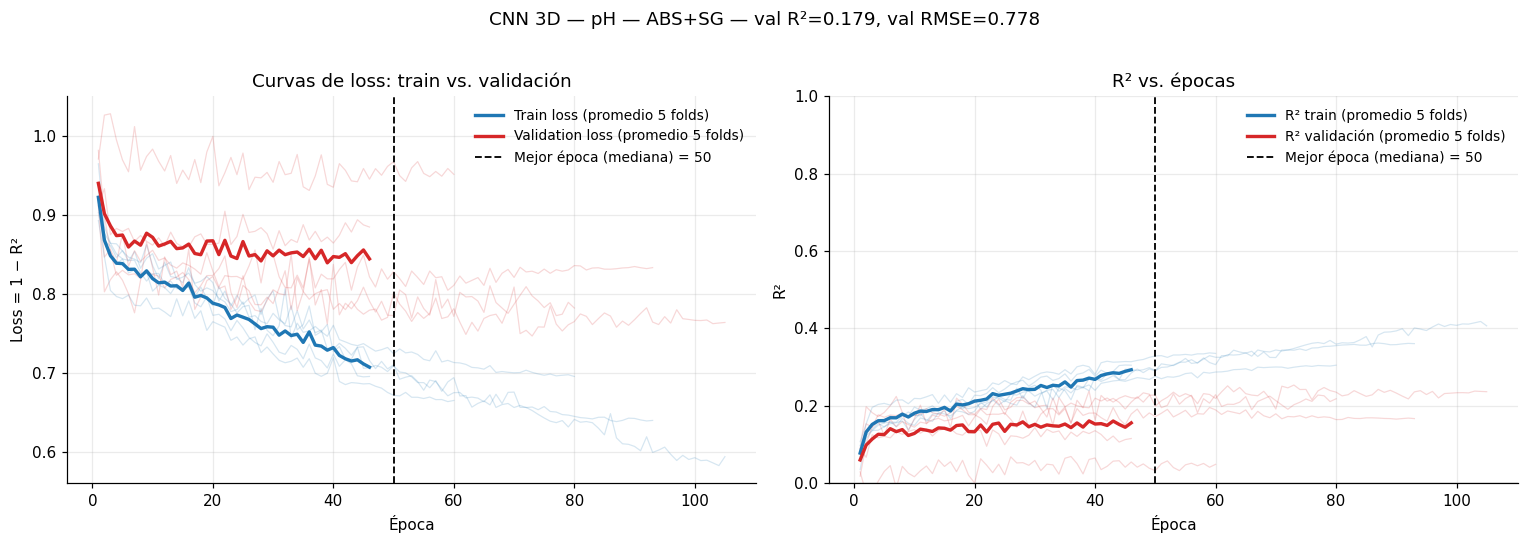


=== CNN 3D — Ca ===
  CNN 3D | Ca | RAW     | identity | val RMSE=7.2246 val R²=0.205 | épocas=[18, 10, 46, 17, 15] | 3.3 min
  CNN 3D | Ca | SG      | identity | val RMSE=7.2134 val R²=0.207 | épocas=[137, 10, 31, 47, 19] | 5.1 min
  CNN 3D | Ca | ABS     | identity | val RMSE=7.2759 val R²=0.194 | épocas=[26, 23, 49, 18, 14] | 4.0 min
  CNN 3D | Ca | ABS+SG  | identity | val RMSE=7.2571 val R²=0.198 | épocas=[51, 30, 64, 16, 39] | 5.0 min


,target,preproceso,transformacion,mejor_epoca_mediana,RMSE,MAE,R2,Bias,RPD,RPIQ
0,Ca,SG,identity,31.0,7.2134,5.5418,0.2075,-0.1509,1.1239,1.3572
1,Ca,RAW,identity,17.0,7.2246,5.6181,0.2050,0.0776,1.1222,1.3551
2,Ca,ABS+SG,identity,39.0,7.2571,5.5769,0.1978,-0.1885,1.1171,1.3490
3,Ca,ABS,identity,23.0,7.2759,5.6241,0.1936,0.0188,1.1143,1.3455


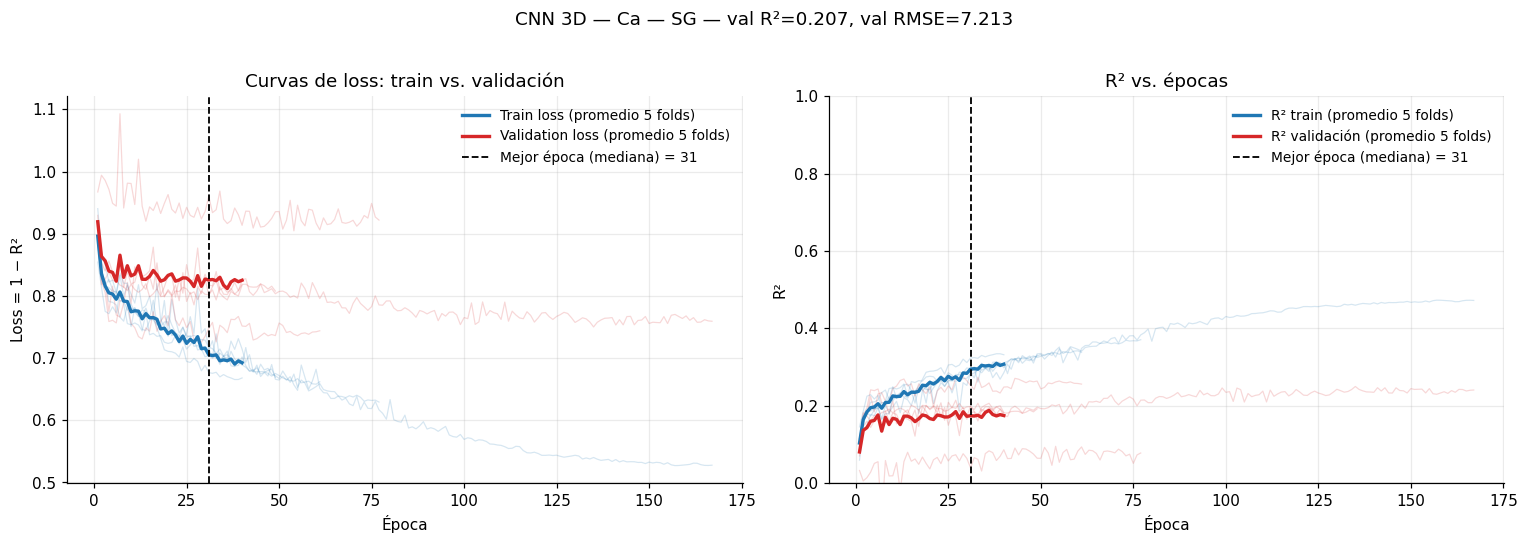

In [20]:
if RUN_CNN_3D:
    for t in TARGETS:
        print(f"\n=== CNN 3D — {t} ===")
        results = [run_cnn_cv("3D", t, mode) for mode in CNN_PREPROCESS_CANDIDATES]
        CNN_RESULTS["3D"][t] = results
        table = cv_table(results)
        table.to_csv(TABLE_DIR / f"cv_cnn3d_{t}.csv", index=False)
        display(table.round(4))
        best = max(results, key=lambda r: r["cv"]["R2"])
        CNN_BEST["3D"][t] = best
        register_cnn(best)
        save_cnn_models(best, f"{t}_CNN3D")
        pd.concat(best["histories"]).to_csv(TABLE_DIR / f"historia_cnn3d_{t}.csv", index=False)
        plot_learning_curves(best, f"14_cnn3d_curvas_{t}")

# 14. Tabla comparativa final: todos los modelos, pH y Ca

Una sola tabla con todos los modelos, ordenada por target y por R² de val (el mejor arriba):

- `input`: qué recibió cada modelo. Los clásicos aparecen dos veces: con la firma `.MAT` (sin sufijo) y con el resumen del cubo (`· cubo media+desv`).
- `val_RMSE`, `val_R2`: validación cruzada de 5 folds sobre las 878 muestras de desarrollo. Con esto se escogió cada modelo.
- `RMSE`, `MAE`, `R2`, `Bias`, `RPD`, `RPIQ`: test (98 muestras que ningún modelo vio).
- `R2_IC95`: intervalo de confianza del 95 % del R² de test (bootstrap). Si los intervalos de dos modelos se solapan, la diferencia entre ellos no es concluyente.
- `Media (referencia)`: predecir siempre el promedio del desarrollo (R² ≈ 0).

In [21]:
MODEL_NAMES = ([n for inp in CLASSICAL_NAMES for n in CLASSICAL_NAMES[inp]]
               + ["CNN_1D", "CNN_3D", "Media (referencia)"])
rows, pred_rows = [], []
for t in TARGETS:
    y_test = Y[t][test_idx]
    for m in MODEL_NAMES:
        if m not in TEST_PRED[t]:
            continue
        pred = TEST_PRED[t][m]
        met = regression_metrics(y_test, pred)
        ci = bootstrap_ci(y_test, pred)
        rows.append({
            "target": t, "model": m, **CONFIG[t][m],
            "val_RMSE": CV_METRICS[t][m]["RMSE"], "val_R2": CV_METRICS[t][m]["R2"],
            **met,
            "R2_IC95": f"[{ci['R2_IC95'][0]:.3f}, {ci['R2_IC95'][1]:.3f}]",
        })
        pred_rows.append(pd.DataFrame({"Numero": df.loc[test_idx, "Numero"].to_numpy(), "target": t,
                                       "model": m, "y_true": y_test, "y_pred": pred}))

final_metrics = pd.DataFrame(rows).sort_values(["target", "val_R2"], ascending=[True, False]).reset_index(drop=True)
final_metrics = final_metrics[["target", "model", "input", "preprocess", "target_transform", "param_name",
                               "param_value", "val_RMSE", "val_R2", "RMSE", "MAE", "R2", "Bias", "RPD", "RPIQ",
                               "R2_IC95"]]
final_metrics.to_csv(TABLE_DIR / "metricas_finales_todos_modelos.csv", index=False)
pd.concat(pred_rows).to_csv(TABLE_DIR / "predicciones_test.csv", index=False)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)
display(final_metrics.round(6))

,target,model,input,preprocess,target_transform,param_name,param_value,val_RMSE,val_R2,RMSE,MAE,R2,Bias,RPD,RPIQ,R2_IC95
0,Ca,CNN_3D,cubo 84x20x20,SG,identity,épocas (mediana),31,7.213353,0.207461,7.963166,6.011646,0.036839,-0.494077,1.024184,1.359070,"[-0.156, 0.195]"
1,Ca,RF · cubo media+desv,cubo: media + desv. por banda (168),SG,identity,"n_estimators, max_features, min_samples_leaf","300, sqrt, 5",7.213618,0.207403,7.985243,6.228075,0.031491,0.086328,1.021352,1.355313,"[-0.198, 0.189]"
2,Ca,RF,firma .MAT (84),SG,identity,"n_estimators, max_features, min_samples_leaf","300, sqrt, 5",7.371338,0.172365,8.099630,6.352208,0.003545,0.019476,1.006928,1.336172,"[-0.218, 0.149]"
3,Ca,CNN_1D,firma .MAT (84),SG,identity,épocas (mediana),16,7.381158,0.170159,7.878067,6.068183,0.057315,-0.130461,1.035247,1.373751,"[-0.124, 0.196]"
4,Ca,Ridge · cubo media+desv,cubo: media + desv. por banda (168),ABS+SG,identity,alpha,100,7.400363,0.165835,8.106811,6.242821,0.001777,-0.232817,1.006036,1.334988,"[-0.193, 0.140]"
5,Ca,Ridge,firma .MAT (84),ABS+SG,identity,alpha,31.6228,7.400660,0.165768,8.004180,6.249724,0.026892,-0.075813,1.018935,1.352106,"[-0.172, 0.159]"
6,Ca,PLSR · cubo media+desv,cubo: media + desv. por banda (168),ABS+SG,identity,n_components,6,7.418003,0.161853,8.065845,6.212880,0.011841,-0.272290,1.011146,1.341769,"[-0.177, 0.151]"
7,Ca,PLSR,firma .MAT (84),ABS+SG,identity,n_components,11,7.423057,0.160711,8.074756,6.260652,0.009656,-0.033639,1.010030,1.340288,"[-0.224, 0.158]"
8,Ca,SVR · cubo media+desv,cubo: media + desv. por banda (168),ABS+SG,identity,"C, gamma, epsilon","10, 0.001, 0.1",7.493475,0.144712,8.299306,5.862864,-0.046190,-1.916106,0.982702,1.304025,"[-0.274, 0.145]"
9,Ca,SVR,firma .MAT (84),ABS,identity,"C, gamma, epsilon","10, 0.001, 0.1",7.496063,0.144121,8.423359,5.907359,-0.077700,-2.016826,0.968229,1.284820,"[-0.310, 0.098]"


# 15. Guardar configuración y comprimir resultados

In [24]:
config = {
    "fecha": time.strftime("%Y-%m-%d %H:%M"),
    "n_muestras": int(len(df)), "n_bandas": int(N_BANDS),
    "rango_nm": [float(wavelengths.min()), float(wavelengths.max())],
    "cubos": {"folder_hint": CUBE_FOLDER_HINT, "mascara": CUBE_USE_MASK, "estadistico": CUBE_SPATIAL_STAT,
              "rango_valido": CUBE_VALID_RANGE, "tamano_cnn3d": CUBE3D_SIZE, "min_valido_bloque": CUBE3D_MIN_VALID},
    "test_size": TEST_SIZE, "n_folds": N_FOLDS, "random_state": RANDOM_STATE,
    "preprocesamientos": PREPROCESS_CANDIDATES, "cnn_preprocesamientos": CNN_PREPROCESS_CANDIDATES,
    "target_transforms": TARGET_TRANSFORMS, "cnn_target_transform": CNN_TARGET_TRANSFORM,
    "entradas_clasicos": {k: v[0] for k, v in CLASSICAL_INPUTS.items()},
    "cnn": {"loss": CNN_LOSS, "max_epochs": CNN_MAX_EPOCHS, "min_epochs": CNN_MIN_EPOCHS, "patience": CNN_PATIENCE,
            "smooth_window": CNN_SMOOTH_WINDOW, "batch": CNN_BATCH_SIZE, "lr": CNN_LR,
            "weight_decay": CNN_WEIGHT_DECAY, "dropout": CNN_DROPOUT, "width": CNN_WIDTH,
            "augment": CNN_AUGMENT, "aug": [AUG_SCALE, AUG_OFFSET, AUG_NOISE], "tta_3d": CNN_TTA_3D},
    "configuracion_ganadora": CONFIG,
    "quick_mode": QUICK_MODE,
}
with open(OUT_DIR / "configuracion_experimento.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False, default=str)

zip_path = shutil.make_archive(str(OUT_DIR), "zip", root_dir=str(OUT_DIR))
print("Todo guardado en:", OUT_DIR.resolve())
print("ZIP:", zip_path)

Todo guardado en: /home/gpu3/Documents/Nohelia/resultados_V23
ZIP: /home/gpu3/Documents/Nohelia/resultados_V23.zip
